# Circunferência e Círculo

**Módulo:** 04 – Geometria Plana

**Pré-requisitos:** [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (medida e comparação de segmentos, ponto médio), [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) (perpendicular por um ponto, distância de ponto a reta, mediatriz e a ideia de **lugar geométrico**, que a circunferência retoma), [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb) (as circunferências inscrita e circunscrita, já usadas informalmente) e [`0411a_poligonos.ipynb`](0411a_poligonos.ipynb) (polígonos convexos e quadriláteros). De forma pontual, [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) (o triângulo isósceles e o caso especial hipotenusa-cateto, que justificam as propriedades das cordas e dos segmentos tangentes).

**Objetivos de aprendizagem:** ao final você será capaz de...
- Definir circunferência como lugar geométrico, distinguir **circunferência** de **círculo** e decidir se um ponto é interior, exterior ou pertence à circunferência.
- Identificar os elementos da circunferência e do círculo (centro, raio, corda, diâmetro, arco, flecha, setor, segmento circular e coroa) e usar as propriedades das cordas.
- Classificar a posição relativa de uma **reta** e uma circunferência, e de **duas circunferências**, comparando distâncias com os raios.
- Aplicar a propriedade dos **segmentos tangentes** traçados de um ponto exterior e o **teorema de Pitot** para quadriláteros circunscritíveis.

**Tempo estimado:** 80 a 95 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/04_geometria_plana/0412a_circunferencia_e_circulo.ipynb)

## O cabrito e a estaca

Um cabrito está amarrado a uma estaca fincada no meio de um pasto, por uma corda de 3 metros. Duas perguntas:

1. Se o cabrito andar mantendo a corda **sempre esticada**, por onde ele passa?
2. E até onde ele consegue **chegar** para comer o capim, agora andando à vontade, com a corda esticada ou frouxa?

Parecem a mesma pergunta, mas não são. Pense um pouco nas duas respostas (dá até para desenhar num papel) antes de continuar.

Até aqui, todas as figuras do módulo foram feitas de **segmentos de reta**: triângulos, quadriláteros, polígonos. A resposta da primeira pergunta é a primeira figura **curva** do curso, e várias ferramentas que você já tem (lugar geométrico, perpendicular, mediatriz, distância de ponto a reta) vão ganhar um palco novo.

Execute a célula abaixo (ela carrega as ferramentas do notebook) e depois a do widget, para soltar o cabrito.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc, Circle, Polygon, Wedge

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Ferramentas de desenho e de medida dos notebooks anteriores (0407a, 0410a e 0411a)
def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice`
    formado pelas semirretas que passam por P e por Q (resultado entre 0° e 180°)."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def cruzamento(P, inclinacao_1: float, Q, inclinacao_2: float):
    """Ponto em que a reta que passa por P (com a inclinação `inclinacao_1`, em graus) cruza a reta
    que passa por Q (com a inclinação `inclinacao_2`). Devolve None se as duas retas tiverem a mesma
    direção, porque aí elas não se cruzam num ponto só.

    Por trás, é um sistema linear 2×2 (módulo 03): P + t·u = Q + k·v, com incógnitas t e k.
    """
    matriz = np.column_stack([direcao(inclinacao_1), -direcao(inclinacao_2)])
    if abs(np.linalg.det(matriz)) < 1e-12:
        return None
    t, _ = np.linalg.solve(matriz, np.subtract(Q, P))
    return np.array(P, dtype=float) + t * direcao(inclinacao_1)


def inclinacao_da_perpendicular(inclinacao_r: float) -> float:
    """Inclinação da perpendicular a uma reta de inclinação `inclinacao_r`: girar 90° (a menos de 180°)."""
    return (inclinacao_r + 90) % 180


def projecao_ortogonal(P, ponto_r, inclinacao_r: float) -> np.ndarray:
    """Projeção ortogonal P' de P sobre a reta r (que passa por `ponto_r`, com a inclinação dada):
    o pé da perpendicular a r traçada por P (0407a)."""
    return cruzamento(P, inclinacao_da_perpendicular(inclinacao_r), ponto_r, inclinacao_r)


def distancia_ponto_reta(P, ponto_r, inclinacao_r: float) -> float:
    """Distância de P à reta r: a medida de PP', com P' a projeção ortogonal de P sobre r (0407a)."""
    return math.dist(P, projecao_ortogonal(P, ponto_r, inclinacao_r))


def ponto_medio(P, Q) -> np.ndarray:
    """Ponto médio do segmento PQ: a média das coordenadas (0402a)."""
    return (np.asarray(P, dtype=float) + np.asarray(Q, dtype=float)) / 2


def mediatriz(A, B) -> tuple[np.ndarray, float]:
    """A mediatriz de AB, descrita como toda reta destes notebooks: um ponto (o ponto médio M) e a
    inclinação (0407a)."""
    return ponto_medio(A, B), inclinacao_da_perpendicular(direcao_de(A, B))


def circuncentro(A, B, C) -> np.ndarray:
    """Circuncentro do triângulo ABC: o cruzamento das mediatrizes de AB e de BC (0410a)."""
    return cruzamento(*mediatriz(A, B), *mediatriz(B, C))


def iguais(x: float, y: float) -> bool:
    """Compara duas medidas com uma tolerância pequena (as contas com float têm arredondamentos)."""
    return math.isclose(x, y, rel_tol=1e-9, abs_tol=1e-6)


def desenhar_ponto(ax, p, nome: str = "", cor: str = COR_AVISO, deslocamento=(0.12, 0.15),
                   tamanho_fonte: int = 13) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=7, zorder=6)
    if nome:
        ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=tamanho_fonte,
                fontweight="bold", zorder=7)


def desenhar_reta(ax, P, Q, cor: str = COR_SECUNDARIA, estilo: str = "-", largura: float = 2.0,
                  alpha: float = 0.9) -> None:
    """Desenha a reta inteira que passa por P e por Q (até a borda do gráfico)."""
    ax.axline(tuple(np.asarray(P, dtype=float)), tuple(np.asarray(Q, dtype=float)), color=cor,
              linestyle=estilo, lw=largura, alpha=alpha, zorder=2)


def desenhar_setor(ax, vertice, inicio: float, abertura: float, raio: float = 0.5, cor: str = COR_PONTO,
                   rotulo: str | None = None, marcar_reto: bool = True, raio_rotulo: float | None = None,
                   tamanho_fonte: int = 11) -> None:
    """Pinta o ângulo com vértice em `vertice` que começa na direção `inicio` e gira `abertura`
    graus no sentido anti-horário. O ângulo reto ganha o quadradinho no lugar do arco."""
    v = np.array(vertice, dtype=float)
    if marcar_reto and math.isclose(abertura, 90, abs_tol=1e-6):
        lado = 0.6 * raio
        canto = [v, v + lado * direcao(inicio), v + lado * (direcao(inicio) + direcao(inicio + 90)),
                 v + lado * direcao(inicio + 90)]
        ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2))
    else:
        ax.add_patch(Wedge(v, raio, inicio, inicio + abertura, facecolor=cor, alpha=0.3, edgecolor="none"))
        ax.add_patch(Arc(v, 2 * raio, 2 * raio, theta1=inicio, theta2=inicio + abertura, color=cor, lw=2))
    if rotulo:
        distancia_rotulo = 1.6 * raio if raio_rotulo is None else raio_rotulo
        posicao = v + distancia_rotulo * direcao(inicio + abertura / 2)
        ax.text(*posicao, rotulo, color=cor, fontsize=tamanho_fonte, ha="center", va="center", fontweight="bold")


def desenhar_arco(ax, vertice, p, q, **opcoes) -> None:
    """Marca o ângulo de vértice `vertice` formado pelas semirretas que passam por p e por q
    (sempre a abertura menor, entre 0° e 180°). Aceita as mesmas opções de `desenhar_setor`."""
    inicio = direcao_de(vertice, p) % 360
    abertura = (direcao_de(vertice, q) - inicio) % 360
    if abertura > 180:
        inicio, abertura = direcao_de(vertice, q) % 360, 360 - abertura
    desenhar_setor(ax, vertice, inicio, abertura, **opcoes)


def marcar_angulo_reto(ax, vertice, p, q, tamanho: float = 0.3, cor: str = COR_DESTAQUE) -> None:
    """Desenha o quadradinho de ângulo reto no `vertice`, entre as semirretas que passam por p e por q."""
    v = np.array(vertice, dtype=float)
    u = np.subtract(p, v) / np.linalg.norm(np.subtract(p, v))
    w = np.subtract(q, v) / np.linalg.norm(np.subtract(q, v))
    canto = [v, v + tamanho * u, v + tamanho * (u + w), v + tamanho * w]
    ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2, zorder=4))


def marcar_congruentes(ax, P, Q, tracos: int = 1, cor: str = NORD_TEXTO, tamanho: float = 0.16) -> None:
    """Tracinhos no meio do segmento PQ: a marca de segmentos congruentes (0402a)."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    u = (Q - P) / np.linalg.norm(Q - P)
    normal = np.array([-u[1], u[0]])
    meio = (P + Q) / 2
    for k in range(tracos):
        centro_traco = meio + (k - (tracos - 1) / 2) * 0.12 * u
        ax.plot(*zip(centro_traco - tamanho * normal, centro_traco + tamanho * normal), color=cor, lw=2,
                zorder=6)


def rotular_segmento(ax, P, Q, texto: str, cor: str, lado: int = 1, distancia: float = 0.3,
                     tamanho: int = 11) -> None:
    """Escreve `texto` junto ao meio do segmento PQ, afastado `distancia` para um dos lados (lado = 1 ou −1)."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    normal = np.array([-(Q - P)[1], (Q - P)[0]]) / np.linalg.norm(Q - P)
    ax.text(*((P + Q) / 2 + lado * distancia * normal), texto, color=cor, fontsize=tamanho, fontweight="bold",
            ha="center", va="center", zorder=7)


def rotular_fora(ax, P, texto: str, centro, cor: str = NORD_TEXTO, distancia: float = 0.35,
                 tamanho: int = 12) -> None:
    """Escreve `texto` perto do ponto P, afastado do `centro` (para não ficar em cima da figura)."""
    P = np.asarray(P, dtype=float)
    afastar = P - np.asarray(centro, dtype=float)
    afastar = afastar / np.linalg.norm(afastar) if np.linalg.norm(afastar) > 0 else np.array([0.0, 1.0])
    ax.text(*(P + distancia * afastar), texto, color=cor, fontsize=tamanho, fontweight="bold",
            ha="center", va="center", zorder=7)


def escrever_checklist(ax, itens, titulo: str = "") -> None:
    """Painel de texto com uma linha por item (texto, ok): ✓ verde quando vale, ✗ vermelho quando não (0410a)."""
    ax.set_facecolor(NORD_FUNDO)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    if titulo:
        ax.text(0.0, 0.97, titulo, color=NORD_TEXTO, fontsize=12, fontweight="bold", va="top")
    passo = min(0.13, 0.85 / max(len(itens), 1))
    for k, (texto, ok) in enumerate(itens):
        ax.text(0.0, 0.84 - k * passo, f"{'✓' if ok else '✗'}  {texto}", color=COR_DESTAQUE if ok else COR_ALERTA,
                fontsize=11, va="top")


# Ferramentas novas deste notebook: a circunferência, com UMA cor fixa para cada elemento
COR_CIRCUNFERENCIA = COR_PONTO  # a linha da circunferência
COR_CIRCUNFERENCIA_2 = COR_EXTRA  # a segunda circunferência, quando há duas
COR_CENTRO = NORD_TEXTO  # o centro
COR_RAIO = COR_DESTAQUE  # raios
COR_CORDA = COR_EXTRA  # cordas
COR_DIAMETRO = "#D08770"  # o diâmetro, a maior corda
COR_ARCO = COR_AVISO  # arcos
COR_FLECHA = COR_ALERTA  # a flecha
CORES_POSICAO = {"interior": COR_DESTAQUE, "sobre a circunferência": COR_AVISO, "exterior": COR_ALERTA}
CORES_RETA = {"exterior": COR_ALERTA, "tangente": COR_AVISO, "secante": COR_SECUNDARIA}


def ponto_na_circunferencia(O, r: float, angulo_graus: float) -> np.ndarray:
    """O ponto da circunferência de centro O e raio r que está na direção `angulo_graus`, vista do centro:
    é só andar r a partir de O nessa direção."""
    return np.asarray(O, dtype=float) + r * direcao(angulo_graus)


def desenhar_circunferencia(ax, O, r: float, cor: str = COR_CIRCUNFERENCIA, estilo: str = "-",
                            largura: float = 2.5, preencher: bool = False, opacidade: float = 0.15) -> None:
    """Desenha a circunferência de centro O e raio r (a linha). Com `preencher=True`, pinta também a
    região interna: o círculo."""
    O = tuple(np.asarray(O, dtype=float))
    if preencher:
        ax.add_patch(Circle(O, r, facecolor=cor, alpha=opacidade, edgecolor="none", zorder=1))
    ax.add_patch(Circle(O, r, fill=False, edgecolor=cor, lw=largura, linestyle=estilo, zorder=3))


def desenhar_arco_da_circunferencia(ax, O, r: float, inicio: float, fim: float, cor: str = COR_ARCO,
                                    largura: float = 5.0) -> None:
    """Destaca o arco da circunferência (O, r) que vai da direção `inicio` até a direção `fim`, em graus,
    no sentido anti-horário."""
    ax.add_patch(Arc(tuple(np.asarray(O, dtype=float)), 2 * r, 2 * r, theta1=inicio, theta2=fim, color=cor,
                     lw=largura, zorder=4))

🕹️ **Widget interativo:** o ponto amarelo é a estaca, e a linha tracejada é a corda que prende o cabrito. O slider `volta` faz o cabrito andar em volta da estaca **com a corda esticada**: o rastro azul é o caminho dele. Leve `volta` até 360° e veja a figura que aparece. Depois marque `mostrar pasto` para ver toda a região que ele alcança, e mude o `comprimento` da corda.

In [ ]:
ESTACA = np.array([0.0, 0.0])


def explorar_cabrito(comprimento: float, volta: int, mostrar_pasto: bool) -> None:
    fig, ax = plt.subplots(figsize=(7.5, 7.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-5.2, -5.2), (5.2, 5.2)], margem=0)
    if mostrar_pasto:
        ax.add_patch(Circle(tuple(ESTACA), comprimento, facecolor=COR_DESTAQUE, alpha=0.3, edgecolor="none"))
    # O rastro do cabrito com a corda esticada: todas as direções de 0° até `volta`
    angulos = np.linspace(0, volta, max(2, volta + 1))
    rastro = np.array([ponto_na_circunferencia(ESTACA, comprimento, a) for a in angulos])
    ax.plot(rastro[:, 0], rastro[:, 1], color=COR_CIRCUNFERENCIA, lw=3.5, zorder=3)
    cabrito = ponto_na_circunferencia(ESTACA, comprimento, volta)
    ax.plot(*zip(ESTACA, cabrito), color=NORD_TEXTO_SEC, lw=2, linestyle="--", zorder=4)
    ax.plot(*ESTACA, "s", color=COR_AVISO, markersize=12, zorder=6)
    ax.text(ESTACA[0] + 0.2, ESTACA[1] - 0.45, "estaca", color=COR_AVISO, fontsize=12, fontweight="bold")
    ax.plot(*cabrito, "o", color=NORD_TEXTO, markersize=16, markeredgecolor=COR_CIRCUNFERENCIA,
            markeredgewidth=2.5, zorder=7)
    rotular_fora(ax, cabrito, "cabrito", ESTACA, distancia=0.75)
    ax.text(*(ponto_medio(ESTACA, cabrito) + 0.35 * direcao(volta + 90)), f"{comprimento:g} m",
            color=NORD_TEXTO_SEC, fontsize=12, ha="center", va="center")
    if volta == 360:
        titulo = f"Volta completa: o caminho é formado por TODOS os pontos a {comprimento:g} m da estaca"
        cor = COR_DESTAQUE
    else:
        titulo = f"Com a corda esticada, o cabrito já andou {volta}° em volta da estaca"
        cor = NORD_TEXTO
    if mostrar_pasto:
        titulo += f"\nem verde, o pasto: todos os pontos a NO MÁXIMO {comprimento:g} m da estaca"
    ax.set_title(titulo, color=cor, fontsize=12)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_cabrito,
    comprimento=widgets.FloatSlider(value=3.0, min=1.0, max=4.5, step=0.5, description="comprimento:"),
    volta=widgets.IntSlider(value=135, min=0, max=360, step=15, description="volta:"),
    mostrar_pasto=widgets.Checkbox(value=False, description="mostrar pasto"),
);

interactive(children=(FloatSlider(value=3.0, description='comprimento:', max=4.5, min=1.0, step=0.5), IntSlide…

Com a corda esticada, o cabrito está sempre a **exatamente** 3 m da estaca, e o rastro de uma volta completa é uma **circunferência**. Já o pasto que ele alcança é toda a região de dentro dessa linha, com a própria linha incluída: um **círculo**. Respondendo às duas perguntas do começo, você separou, sem perceber, as duas palavras-chave deste notebook:

- **circunferência**: o **contorno**, os pontos a uma distância **igual** a 3 m da estaca;
- **círculo**: o **disco**, os pontos a uma distância **menor ou igual** a 3 m.

A mesma figura aparece por toda parte. O **compasso** é um cabrito de metal: a ponta seca é a estaca (o centro) e a abertura é a corda (o raio). Uma **pedra jogada num lago** faz ondas circulares, porque a perturbação se espalha com a mesma velocidade em todas as direções e, a cada instante, atinge todos os pontos a uma mesma distância de onde a pedra caiu. E o **alcance de um roteador de Wi-Fi** ou de uma antena de celular é, aproximadamente, um círculo, com a circunferência marcando a fronteira do sinal.

💡 **Dica:** repare que a "corda" do cabrito, em geometria, se chama **raio**. A palavra **corda** existe em geometria, mas significa outra coisa, como você vai ver na seção 2.

**Uma pergunta antiga, com nome novo.** Em [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb), três casas queriam dividir **um** poste de internet, com os três cabos do mesmo comprimento, e a resposta foi o **circuncentro**, o encontro das mediatrizes. Com o vocabulário deste notebook: se os três cabos medem o mesmo, as três casas estão à mesma distância do poste, ou seja, estão **sobre uma circunferência** com centro no poste. O circuncentro é o **centro da circunferência que passa pelos três pontos**.

comprimento de cada cabo: [3.655, 3.655, 3.655]


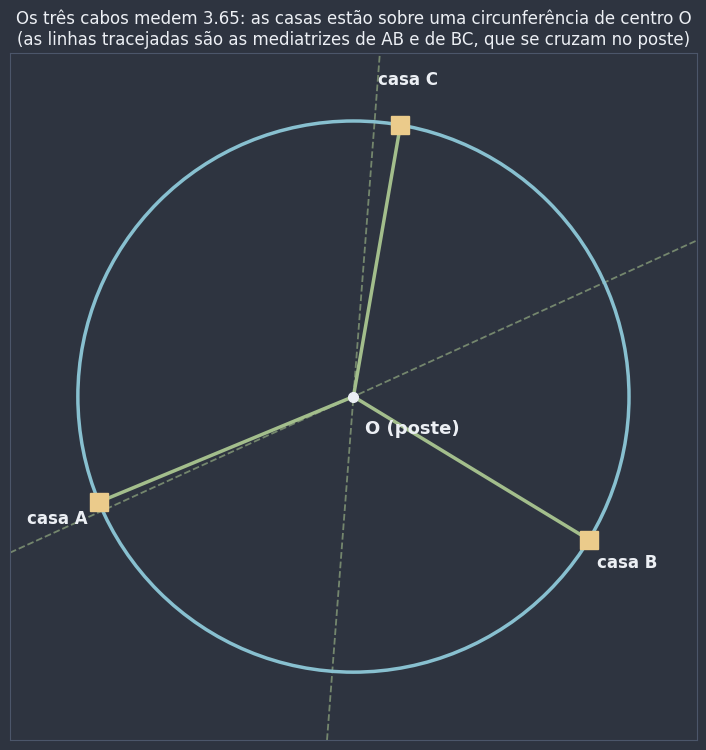

In [3]:
casas = [np.array(p) for p in [(-3.0, -1.5), (3.5, -2.0), (1.0, 3.5)]]
poste = circuncentro(*casas)
cabo = math.dist(poste, casas[0])

fig, ax = plt.subplots(figsize=(8, 7.6))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [poste - cabo, poste + cabo], margem=0.9)
for A, B in ((casas[0], casas[1]), (casas[1], casas[2])):  # duas mediatrizes bastam
    M, inclinacao = mediatriz(A, B)
    desenhar_reta(ax, M, M + direcao(inclinacao), cor=COR_DESTAQUE, estilo="--", largura=1.3, alpha=0.6)
desenhar_circunferencia(ax, poste, cabo)
for casa, nome in zip(casas, "ABC"):
    ax.plot(*zip(poste, casa), color=COR_RAIO, lw=2.5, zorder=4)
    ax.plot(*casa, "s", color=COR_AVISO, markersize=13, zorder=6)
    rotular_fora(ax, casa, f"casa {nome}", poste, distancia=0.6)
desenhar_ponto(ax, poste, "O (poste)", cor=COR_CENTRO, deslocamento=(0.15, -0.5))
print("comprimento de cada cabo:", [round(math.dist(poste, casa), 4) for casa in casas])
ax.set_title(f"Os três cabos medem {cabo:.2f}: as casas estão sobre uma circunferência de centro O\n"
             "(as linhas tracejadas são as mediatrizes de AB e de BC, que se cruzam no poste)",
             color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

### O fio condutor deste notebook

Quase tudo o que vem a seguir se resume a **comparar uma distância com o raio**:

| Seção | O que se compara com o raio $r$ | Para decidir... |
|---|---|---|
| 1. A circunferência como lugar geométrico | a distância de um **ponto** ao centro | se o ponto é interior, exterior ou está na circunferência |
| 2. Elementos da circunferência e do círculo | a distância do centro a uma **corda** | o comprimento da corda e da flecha |
| 3. Reta e circunferência | a distância do centro a uma **reta** | se a reta é exterior, tangente ou secante |
| 4. Duas circunferências | a distância **entre os centros** (com a soma e a diferença dos raios) | qual das seis posições relativas acontece |
| 5. Segmentos tangentes e quadriláteros circunscritíveis | — | as consequências da reta tangente: segmentos tangentes congruentes e o teorema de Pitot |

## 1. A circunferência como lugar geométrico

O cabrito já deu a definição; agora é só escrevê-la com cuidado.

📌 **Definição formal (circunferência):** dados um ponto $O$ de um plano e uma medida $r > 0$, a **circunferência de centro $O$ e raio $r$** é o conjunto de **todos** os pontos do plano que estão à distância $r$ de $O$:

$$\lambda(O, r) = \{\, P \text{ do plano} : OP = r \,\}.$$

As notações mais comuns são $\lambda(O, r)$ (lê-se "lambda de $O$, $r$") e $C(O, r)$.

📌 **Definição formal (círculo):** o **círculo** de centro $O$ e raio $r$ é a reunião da circunferência $\lambda(O, r)$ com a região interna a ela, ou seja, o conjunto dos pontos do plano a uma distância **menor ou igual** a $r$ de $O$: $\{\, P : OP \leq r \,\}$. A circunferência é o **contorno**; o círculo é o **disco**.

Comparando $OP$ com $r$, todo ponto $P$ do plano cai em exatamente um de três casos:

| Comparação | Posição de $P$ | No cabrito |
|---|---|---|
| $OP < r$ | **interior** à circunferência | capim que ele alcança com a corda frouxa |
| $OP = r$ | **pertence** à circunferência ($P \in \lambda$) | o caminho com a corda esticada |
| $OP > r$ | **exterior** à circunferência | capim fora do alcance |

📌 **Lugar geométrico, terceiro exemplo:** em [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb), um **lugar geométrico** foi definido como o conjunto de **todos** os pontos que têm uma propriedade, e **só** deles. A própria definição de circunferência já está nesse formato, e ela fecha o trio de lugares geométricos clássicos do plano, prometido lá atrás:

| Lugar geométrico | Os pontos que são... | Onde apareceu |
|---|---|---|
| **mediatriz** de $\overline{AB}$ | equidistantes de **dois pontos**, $A$ e $B$ | [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) |
| **bissetriz** de um ângulo | equidistantes dos **dois lados** do ângulo | [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb) |
| **circunferência** $\lambda(O, r)$ | à distância $r$ de **um ponto**, $O$ | aqui |

**No código:** a função `posicao_ponto(P, O, r)` faz exatamente a comparação da tabela. Como as contas com `float` têm pequenos arredondamentos, o "igual" usa a função `iguais` (de [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb)), que aceita uma diferença minúscula. Primeiro, a representação numérica, com a circunferência de centro $O = (0, 0)$ e raio 5:

In [4]:
def posicao_ponto(P, O, r: float) -> str:
    """Posição do ponto P em relação à circunferência λ(O, r): 'interior', 'sobre a circunferência'
    ou 'exterior'. Basta comparar a distância OP com o raio."""
    OP = math.dist(P, O)
    if iguais(OP, r):
        return "sobre a circunferência"
    return "interior" if OP < r else "exterior"



O = np.array([0.0, 0.0])
r = 5.0
pontos = {"A": (3, 4), "B": (1, 2), "C": (6, 2), "D": (0, -5), "E": (-4, -4), "F": (-2, 3)}

linhas = []
for nome, P in pontos.items():
    OP = math.dist(P, O)
    sinal = "=" if iguais(OP, r) else ("<" if OP < r else ">")
    linhas.append({"ponto": nome, "coordenadas": str(P), "distância OP": f"{OP:.2f}",
                   "comparação": f"OP {sinal} r", "posição": posicao_ponto(P, O, r)})
display(pd.DataFrame(linhas).style.hide(axis="index"))

ponto,coordenadas,distância OP,comparação,posição
A,"(3, 4)",5.00,OP = r,sobre a circunferência
B,"(1, 2)",2.24,OP < r,interior
C,"(6, 2)",6.32,OP > r,exterior
D,"(0, -5)",5.00,OP = r,sobre a circunferência
E,"(-4, -4)",5.66,OP > r,exterior
F,"(-2, 3)",3.61,OP < r,interior


E a representação gráfica: a linha azul é a circunferência, a região pintada (junto com a linha) é o círculo, e cada ponto tem a cor da sua posição, com a distância ao centro tracejada.

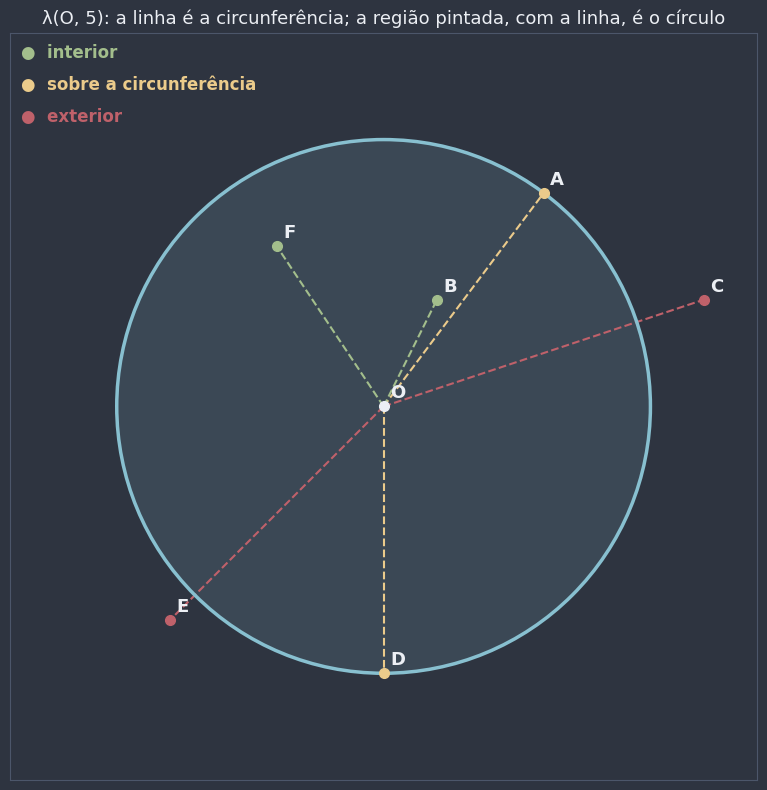

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-7, -7), (7, 7)], margem=0)
desenhar_circunferencia(ax, O, r, preencher=True)
desenhar_ponto(ax, O, "O", cor=COR_CENTRO)
for nome, P in pontos.items():
    cor = CORES_POSICAO[posicao_ponto(P, O, r)]
    ax.plot(*zip(O, P), color=cor, lw=1.5, linestyle="--", zorder=2)
    desenhar_ponto(ax, P, nome, cor=cor)
for k, (posicao, cor) in enumerate(CORES_POSICAO.items()):
    ax.text(-6.8, 6.8 - 0.6 * k, f"●  {posicao}", color=cor, fontsize=12, fontweight="bold", va="top")
ax.set_title("λ(O, 5): a linha é a circunferência; a região pintada, com a linha, é o círculo",
             color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** os sliders `x de P` e `y de P` movem o ponto $P$, e o slider `raio` muda o tamanho da circunferência de centro $O = (0, 0)$. A faixa verde larga é um raio desenhado na direção de $P$, para você comparar com o segmento $\overline{OP}$ tracejado. O painel da direita mostra qual das três comparações vale. Desafio: com raio 5, encontre pontos de coordenadas **inteiras** que fiquem exatamente **sobre** a circunferência (há 12 deles!).

In [6]:
def explorar_posicao(x_P: float, y_P: float, raio: float) -> None:
    O_w = np.array([0.0, 0.0])
    P = np.array([x_P, y_P])
    OP = math.dist(P, O_w)
    posicao = posicao_ponto(P, O_w, raio)
    cor = CORES_POSICAO[posicao]
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(13.5, 6.4), gridspec_kw={"width_ratios": [1.2, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-6.5, -6.5), (6.5, 6.5)], margem=0)
    desenhar_circunferencia(ax, O_w, raio, preencher=True)
    # Um raio de referência, apontando para P (ou para a direita, se P = O)
    angulo = direcao_de(O_w, P) if OP > 1e-9 else 0.0
    ax.plot(*zip(O_w, ponto_na_circunferencia(O_w, raio, angulo)), color=COR_RAIO, lw=9, alpha=0.35,
            solid_capstyle="butt", zorder=2)
    if OP > 1e-9:
        ax.plot(*zip(O_w, P), color=cor, lw=2.2, linestyle="--", zorder=5)
    desenhar_ponto(ax, O_w, "O", cor=COR_CENTRO, deslocamento=(-0.45, -0.5))
    desenhar_ponto(ax, P, "P", cor=cor)
    ax.set_title(f"P = ({x_P:g}, {y_P:g}): {posicao}", color=cor, fontsize=14)
    itens = [
        ("OP < r   →   P é interior", posicao == "interior"),
        ("OP = r   →   P pertence à circunferência", posicao == "sobre a circunferência"),
        ("OP > r   →   P é exterior", posicao == "exterior"),
    ]
    escrever_checklist(ax_lista, itens, f"OP = {OP:.3f}    e    r = {raio:g}")
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_posicao,
    x_P=widgets.FloatSlider(value=3.0, min=-6, max=6, step=0.5, description="x de P:"),
    y_P=widgets.FloatSlider(value=4.0, min=-6, max=6, step=0.5, description="y de P:"),
    raio=widgets.FloatSlider(value=5.0, min=1, max=6, step=0.5, description="raio:"),
);

interactive(children=(FloatSlider(value=3.0, description='x de P:', max=6.0, min=-6.0, step=0.5), FloatSlider(…

⚠️ **Erro comum:** usar "círculo" e "circunferência" como sinônimos. No dia a dia isso é aceito, mas em geometria a diferença tem consequência: o **comprimento** (uma medida de linha) é da **circunferência**, e a **área** (uma medida de região) é do **círculo**. Não faz sentido falar em "área da circunferência", assim como não faz sentido falar em "área do contorno de um quadrado". As duas medidas ficam para 📌 Polígonos Regulares e Comprimento da Circunferência e 📌 Áreas de Superfícies Planas.

🎯 **Aplicação prática — cobertura de sinal:** uma operadora que instala uma antena de celular trabalha com o **círculo** de cobertura (as casas atendidas) e com a **circunferência** que o limita (a fronteira, onde o sinal fica fraco). Decidir se uma casa está coberta é exatamente o teste de `posicao_ponto`: medir a distância da casa até a antena e comparar com o raio de alcance. Com **duas** antenas, a pergunta passa a ser como as duas circunferências se posicionam uma em relação à outra (se há sobreposição, se há buraco entre elas), e é isso que a seção 4 vai responder.

📖 **Leitura complementar:** [Circunferência](https://pt.wikipedia.org/wiki/Circunfer%C3%AAncia), [Círculo](https://pt.wikipedia.org/wiki/C%C3%ADrculo) e [Lugar geométrico](https://pt.wikipedia.org/wiki/Lugar_geom%C3%A9trico)

**Pergunta de checagem:** um ponto $P$ está a 7 cm do centro de uma circunferência de raio 5 cm. Ele é interior, exterior ou pertence a ela? E se a circunferência tivesse raio 7 cm?

**Pergunta de checagem:** o centro $O$ pertence à circunferência $\lambda(O, r)$? E ao círculo de centro $O$ e raio $r$?

## 2. Elementos da circunferência e do círculo

Toda figura tem seus elementos com nome (o triângulo tem vértices, lados, alturas...). Os da circunferência são estes:

| Elemento | O que é |
|---|---|
| **centro** $O$ | o ponto fixo da definição |
| **raio** | o segmento que liga o centro a um ponto da circunferência; a sua medida, $r$, também é chamada de raio |
| **corda** | o segmento cujas extremidades são dois pontos **da circunferência** |
| **diâmetro** | a corda que **passa pelo centro**; mede $2r$ (dois raios em linha) |
| **arco** | cada uma das duas partes em que dois pontos $A$ e $B$ dividem a circunferência; notação $\overset{\frown}{AB}$ |
| **semicircunferência** | o arco cujas extremidades são as de um diâmetro: metade da circunferência |
| **flecha** | o segmento, sobre a perpendicular à corda pelo seu ponto médio $M$, que vai da corda até o arco |

E as **regiões** do círculo:

| Região | O que é |
|---|---|
| **setor circular** | a região limitada por **dois raios** e o arco entre eles (uma "fatia de pizza") |
| **segmento circular** | a região limitada por **uma corda** e um dos arcos que ela determina |
| **coroa circular** | a região entre **duas circunferências concêntricas** (de mesmo centro): um "anel" |

Primeiro, os elementos que são linhas e segmentos, cada um com a sua cor (as mesmas cores valem para o notebook inteiro):

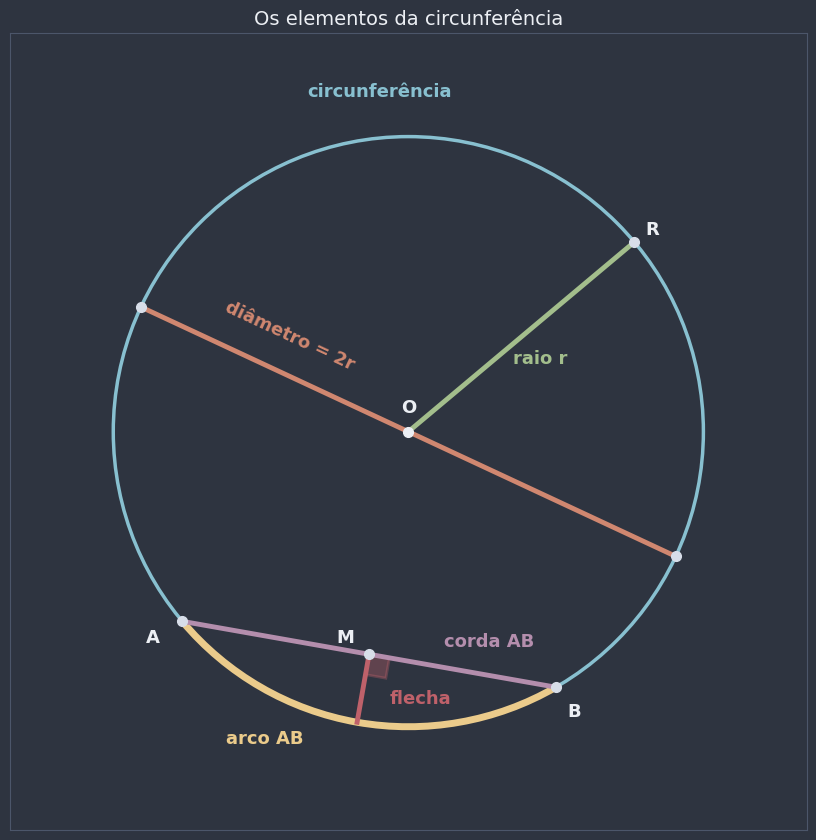

In [7]:
O, r = np.array([0.0, 0.0]), 4.0
R = ponto_na_circunferencia(O, r, 40)
D1, D2 = ponto_na_circunferencia(O, r, 155), ponto_na_circunferencia(O, r, 335)
A, B = ponto_na_circunferencia(O, r, 220), ponto_na_circunferencia(O, r, 300)
M = ponto_medio(A, B)
F = ponto_na_circunferencia(O, r, 260)  # o ponto do arco AB "em frente" a M

fig, ax = plt.subplots(figsize=(8.5, 8.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-r, -r), (r, r)], margem=1.4)
desenhar_circunferencia(ax, O, r)
desenhar_arco_da_circunferencia(ax, O, r, 220, 300)
ax.plot(*zip(O, R), color=COR_RAIO, lw=3.5, zorder=5)
ax.plot(*zip(D1, D2), color=COR_DIAMETRO, lw=3.5, zorder=5)
ax.plot(*zip(A, B), color=COR_CORDA, lw=3.5, zorder=5)
ax.plot(*zip(M, F), color=COR_FLECHA, lw=3.5, zorder=5)
marcar_angulo_reto(ax, M, B, F, tamanho=0.28, cor=COR_FLECHA)
rotular_segmento(ax, O, R, "raio r", COR_RAIO, lado=-1, distancia=0.4, tamanho=13)
ax.text(*(D1 + 0.25 * (D2 - D1) + np.array([0.2, 0.45])), "diâmetro = 2r", color=COR_DIAMETRO, fontsize=13,
        fontweight="bold", ha="center", va="center", rotation=direcao_de(D2, D1) - 180)
ax.text(1.1, -2.85, "corda AB", color=COR_CORDA, fontsize=13, fontweight="bold", ha="center", va="center")
ax.text(-0.25, -3.62, "flecha", color=COR_FLECHA, fontsize=13, fontweight="bold", ha="left", va="center")
ax.text(*ponto_na_circunferencia(O, r + 0.6, 245), "arco AB", color=COR_ARCO, fontsize=13, fontweight="bold",
        ha="center", va="center")
ax.text(*ponto_na_circunferencia(O, r + 0.55, 95), "circunferência", color=COR_CIRCUNFERENCIA, fontsize=13,
        fontweight="bold", ha="center")
for P, nome, desloc in ((A, "A", (-0.5, -0.3)), (B, "B", (0.15, -0.4)), (M, "M", (-0.45, 0.15)),
                        (R, "R", (0.15, 0.1)), (D1, "", (0, 0)), (D2, "", (0, 0))):
    desenhar_ponto(ax, P, nome, cor=NORD_TEXTO_SEC, deslocamento=desloc)
desenhar_ponto(ax, O, "O", cor=COR_CENTRO, deslocamento=(-0.1, 0.25))
ax.set_title("Os elementos da circunferência", color=NORD_TEXTO, fontsize=14)
plt.tight_layout()
plt.show()

Repare que o diâmetro divide a circunferência em duas **semicircunferências**, e que a corda $\overline{AB}$ divide a circunferência em **dois** arcos: o menor, destacado em amarelo, e o maior, que dá a volta pelo outro lado. Quando se fala "o arco $\overset{\frown}{AB}$" sem dizer qual, entende-se em geral o menor.

Agora as três regiões do círculo:

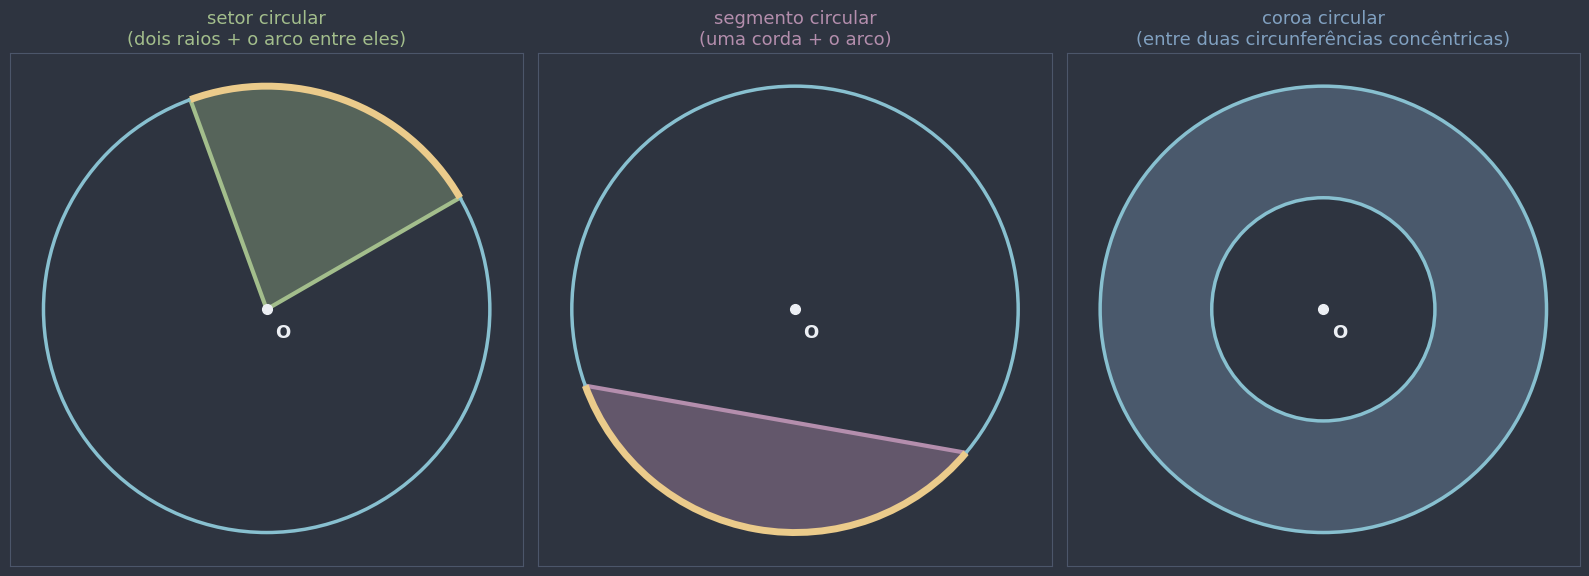

In [8]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 5.8))
fig.patch.set_facecolor(NORD_FUNDO)
for ax in eixos:
    preparar_eixo(ax, [(-r, -r), (r, r)], margem=0.6)
    desenhar_circunferencia(ax, O, r)
    desenhar_ponto(ax, O, "O", cor=COR_CENTRO, deslocamento=(0.15, -0.5))

# Setor circular: dois raios e o arco entre eles
ax = eixos[0]
ax.add_patch(Wedge(tuple(O), r, 30, 110, facecolor=COR_RAIO, alpha=0.35, edgecolor="none"))
for angulo in (30, 110):
    ax.plot(*zip(O, ponto_na_circunferencia(O, r, angulo)), color=COR_RAIO, lw=3)
desenhar_arco_da_circunferencia(ax, O, r, 30, 110)
ax.set_title("setor circular\n(dois raios + o arco entre eles)", color=COR_RAIO, fontsize=13)

# Segmento circular: uma corda e o arco correspondente
ax = eixos[1]
contorno = [ponto_na_circunferencia(O, r, a) for a in np.linspace(200, 320, 80)]
ax.add_patch(Polygon(contorno, closed=True, facecolor=COR_CORDA, alpha=0.4, edgecolor="none"))
ax.plot(*zip(contorno[0], contorno[-1]), color=COR_CORDA, lw=3)
desenhar_arco_da_circunferencia(ax, O, r, 200, 320)
ax.set_title("segmento circular\n(uma corda + o arco)", color=COR_CORDA, fontsize=13)

# Coroa circular: entre duas circunferências concêntricas
ax = eixos[2]
ax.add_patch(Wedge(tuple(O), r, 0, 360, width=r / 2, facecolor=COR_SECUNDARIA, alpha=0.35, edgecolor="none"))
desenhar_circunferencia(ax, O, r / 2)
ax.set_title("coroa circular\n(entre duas circunferências concêntricas)", color=COR_SECUNDARIA, fontsize=13)
plt.tight_layout()
plt.show()

### Três propriedades das cordas

As cordas de uma circunferência obedecem a três regras, e cada uma sai de uma ferramenta que você já tem.

**1. O diâmetro é a maior corda.** Seja $\overline{AB}$ uma corda qualquer. Pela desigualdade triangular ([`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb)) aplicada aos pontos $O$, $A$ e $B$:

$$AB \leq AO + OB = r + r = 2r,$$

com a igualdade valendo só quando $O$ está **sobre** o segmento $\overline{AB}$, isto é, quando a corda é um diâmetro.

**2. A perpendicular baixada do centro a uma corda passa pelo ponto médio da corda.** O triângulo $OAB$ é **isósceles**, porque $OA = OB = r$. Num triângulo isósceles, a altura relativa à base também é mediana ([`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) e [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb)). Então o pé $M$ da perpendicular de $O$ a $\overline{AB}$ é o ponto médio de $\overline{AB}$. Dito pelo outro lado: como $OA = OB$, o centro está na **mediatriz** de $\overline{AB}$ (o lugar geométrico de [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb)). Logo, **a mediatriz de qualquer corda passa pelo centro**.

**3. Cordas congruentes estão à mesma distância do centro, e vice-versa.** Para uma corda de comprimento $c$ a uma distância $d$ do centro, o triângulo $OMA$ é **retângulo** em $M$, com hipotenusa $OA = r$ e catetos $OM = d$ e $MA = \frac{c}{2}$. Duas cordas de mesmo comprimento produzem triângulos retângulos com a hipotenusa e um cateto congruentes; pelo caso especial **hipotenusa-cateto** (o Exercício Intermediário 4 de [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb)), esses triângulos são congruentes, e então as distâncias $d$ também são iguais. A volta é igual: mesma $d$, mesma hipotenusa, triângulos congruentes, mesmo $c$.

**No código:** a função `elementos_da_corda` mede o comprimento $c$, a distância $d$ do centro à corda e a flecha $r - d$ (do lado do arco menor). A tabela mostra várias cordas horizontais de uma circunferência de raio 4, da mais longa (o diâmetro) para as mais curtas. As duas últimas colunas são uma **conferência numérica**: no triângulo retângulo $OMA$, os números sempre satisfazem $r^2 = d^2 + \left(\frac{c}{2}\right)^2$. Isso é o **Teorema de Pitágoras**, que será demonstrado em 📌 Triângulos Retângulos; aqui ele aparece só como uma regularidade dos números.

In [9]:
def elementos_da_corda(O, r: float, A, B) -> dict[str, float]:
    """Medidas da corda AB da circunferência λ(O, r): o comprimento c = AB, a distância d do centro à
    corda (a medida de OM, com M o ponto médio de AB, que é o pé da perpendicular baixada de O) e a
    flecha r − d (do lado do arco menor)."""
    M = ponto_medio(A, B)
    c = math.dist(A, B)
    d = math.dist(O, M)
    return {"c": c, "d": d, "flecha": r - d}



linhas = []
for meia_abertura in [90, 75, 60, 45, 30, 15]:
    # corda horizontal, com as pontas simétricas em relação à vertical que passa pelo centro
    A_k = ponto_na_circunferencia(O, r, 270 - meia_abertura)
    B_k = ponto_na_circunferencia(O, r, 270 + meia_abertura)
    medidas = elementos_da_corda(O, r, A_k, B_k)
    M_k = ponto_medio(A_k, B_k)
    perpendicular = "M = O (diâmetro)" if iguais(medidas["d"], 0) else f"{medir_angulo(M_k, O, A_k):.1f}°"
    linhas.append({
        "corda c": f"{medidas['c']:.3f}",
        "distância d": f"{medidas['d']:.3f}",
        "flecha r − d": f"{medidas['flecha']:.3f}",
        "ângulo OM̂A": perpendicular,
        "r²": f"{r**2:.3f}",
        "d² + (c/2)²": f"{medidas['d']**2 + (medidas['c'] / 2)**2:.3f}",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

corda c,distância d,flecha r − d,ângulo OM̂A,r²,d² + (c/2)²
8.000,0.000,4.000,M = O (diâmetro),16.000,16.000
7.727,1.035,2.965,90.0°,16.000,16.000
6.928,2.000,2.000,90.0°,16.000,16.000
5.657,2.828,1.172,90.0°,16.000,16.000
4.000,3.464,0.536,90.0°,16.000,16.000
2.071,3.864,0.136,90.0°,16.000,16.000


Leia a tabela de cima para baixo: quanto **mais longe** do centro, **mais curta** a corda e **menor** a flecha. A maior corda é a da primeira linha ($d = 0$, o diâmetro, com $c = 2r = 8$). O ângulo $O\hat{M}A$ é sempre 90° (propriedade 2), e as duas últimas colunas sempre coincidem.

🕹️ **Widget interativo:** o slider `distância` afasta a corda do centro, e o slider `giro` gira tudo em volta de $O$. Acompanhe no painel o comprimento da corda, a flecha e as verificações. A reta verde tracejada é a **mediatriz** da corda: repare que ela passa sempre pelo centro. Leve a `distância` até 0 e veja a corda virar diâmetro.

In [10]:
def explorar_corda(distancia: float, giro: int) -> None:
    O_w, r_w = np.array([0.0, 0.0]), 4.0
    normal = direcao(giro)  # direção de O para o ponto médio M da corda
    M_w = O_w + distancia * normal
    # meia corda pelo Teorema de Pitágoras (📌 Triângulos Retângulos); aqui só serve para desenhar
    meia = math.sqrt(r_w**2 - distancia**2)
    A_w, B_w = M_w - meia * direcao(giro + 90), M_w + meia * direcao(giro + 90)
    medidas = elementos_da_corda(O_w, r_w, A_w, B_w)
    eh_diametro = iguais(distancia, 0)
    F_w = ponto_na_circunferencia(O_w, r_w, giro)

    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 6.6), gridspec_kw={"width_ratios": [1.15, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-r_w, -r_w), (r_w, r_w)], margem=0.8)
    desenhar_circunferencia(ax, O_w, r_w)
    abertura = 2 * math.degrees(math.acos(distancia / r_w))  # o arco menor AB, visto do centro
    desenhar_arco_da_circunferencia(ax, O_w, r_w, giro - abertura / 2, giro + abertura / 2)
    if eh_diametro:
        ax.plot(*zip(A_w, B_w), color=COR_DIAMETRO, lw=4, zorder=5)
        titulo, cor_titulo = "d = 0: a corda passa por O e vira o DIÂMETRO, a maior corda", COR_DIAMETRO
    else:
        desenhar_reta(ax, O_w, M_w, cor=COR_DESTAQUE, estilo="--", largura=1.3, alpha=0.7)  # mediatriz
        ax.plot(*zip(O_w, M_w), color=NORD_TEXTO_SEC, lw=2, zorder=4)
        rotular_segmento(ax, O_w, M_w, "d", NORD_TEXTO_SEC, lado=1, distancia=0.25, tamanho=13)
        ax.plot(*zip(M_w, F_w), color=COR_FLECHA, lw=3.5, zorder=5)
        ax.plot(*zip(A_w, B_w), color=COR_CORDA, lw=4, zorder=5)
        marcar_angulo_reto(ax, M_w, B_w, O_w, tamanho=0.3)
        titulo, cor_titulo = f"corda a {distancia:.1f} do centro: c = {medidas['c']:.2f}", COR_CORDA
    marcar_congruentes(ax, A_w, M_w)
    marcar_congruentes(ax, M_w, B_w)
    for P, nome in ((A_w, "A"), (B_w, "B"), (M_w, "M" if not eh_diametro else "")):
        desenhar_ponto(ax, P, nome, cor=NORD_TEXTO_SEC)
    desenhar_ponto(ax, O_w, "O", cor=COR_CENTRO, deslocamento=(-0.4, -0.45))
    ax.set_title(titulo, color=cor_titulo, fontsize=13)

    AM, MB = math.dist(A_w, M_w), math.dist(M_w, B_w)
    itens = [
        (f"AM = {AM:.2f} e MB = {MB:.2f}: M é o ponto médio", iguais(AM, MB)),
        ("a corda passa por O: é um diâmetro" if eh_diametro
         else f"OM ⊥ AB (∠OMA = {medir_angulo(M_w, O_w, A_w):.1f}°)", True),
        (f"comprimento c = {medidas['c']:.2f}  ≤  2r = {2 * r_w:g}", medidas["c"] <= 2 * r_w + 1e-9),
        (f"flecha = r − d = {medidas['flecha']:.2f}", True),
        (f"r² = {r_w**2:.2f}  e  d² + (c/2)² = {distancia**2 + (medidas['c'] / 2)**2:.2f}",
         iguais(r_w**2, distancia**2 + (medidas["c"] / 2) ** 2)),
    ]
    escrever_checklist(ax_lista, itens, f"r = {r_w:g}     d = {distancia:.1f}")
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_corda,
    distancia=widgets.FloatSlider(value=2.0, min=0, max=3.8, step=0.1, description="distância:"),
    giro=widgets.IntSlider(value=270, min=0, max=360, step=15, description="giro:"),
);

interactive(children=(FloatSlider(value=2.0, description='distância:', max=3.8), IntSlider(value=270, descript…

💡 **Dica:** para não confundir, lembre que a **corda** é sempre **reta** (um segmento), e o **arco** é sempre **curvo** (um pedaço da circunferência). Uma corda e o seu arco "se enxergam": diz-se que a corda **subtende** o arco.

📎 **Conexão:** a propriedade "a mediatriz de uma corda passa pelo centro" explica por que o **circuncentro** de [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb) é o centro da circunferência circunscrita. Os três lados do triângulo são **cordas** dessa circunferência, então as três mediatrizes passam pelo centro dela. Foi exatamente o que a figura das três casas mostrou no começo do notebook.

🎯 **Aplicação prática — o raio de uma peça sem centro:** numa oficina, como medir o raio de um pedaço de cano largo, de um arco de janela ou de uma peça circular quebrada, se o centro não está ali para medir? Mede-se uma **corda** $c$ (com uma régua apoiada em dois pontos da borda) e a **flecha** $f$ (a maior distância entre a régua e a borda). Como $d = r - f$, a conferência numérica $r^2 = d^2 + \left(\frac{c}{2}\right)^2$ vira $r^2 = (r - f)^2 + \frac{c^2}{4}$, e isolando $r$:

$$r = \frac{c^2/4 + f^2}{2f}.$$

Com uma corda de 40 cm e uma flecha de 5 cm, por exemplo: $r = \frac{400 + 25}{10} = 42{,}5$ cm. Existem até instrumentos (os **esferômetros**) que fazem essa conta para medir a curvatura de lentes.

📖 **Leitura complementar:** [Corda (geometria)](https://pt.wikipedia.org/wiki/Corda_%28geometria%29)

**Pergunta de checagem:** uma corda de 16 cm está a 6 cm do centro de uma circunferência. Qual é o raio? (Use a conferência numérica da tabela.)

**Pergunta de checagem:** numa mesma circunferência, uma corda está a 2 cm do centro e outra está a 5 cm. Qual delas é a maior? Por quê?

## 3. Posições relativas de reta e circunferência

Uma reta e uma circunferência podem ter **dois**, **um** ou **nenhum** ponto em comum. Quem decide é a mesma comparação da seção 1, só que agora com a distância do centro até a **reta**.

Dada a circunferência $\lambda(O, r)$ e uma reta $s$, seja $d$ a **distância de $O$ a $s$** (a medida da perpendicular de $O$ até $s$, de [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb)):

| Comparação | Posição da reta $s$ | Pontos em comum |
|---|---|---|
| $d > r$ | **exterior** | nenhum |
| $d = r$ | **tangente** | exatamente um: o **ponto de tangência** $T$ |
| $d < r$ | **secante** | dois (e o pedaço de $s$ entre eles é uma **corda**) |

📌 **Definição formal (reta tangente):** uma reta é **tangente** a uma circunferência quando tem com ela **um único** ponto em comum, o ponto de tangência.

📌 **Propriedade fundamental:** a reta tangente é **perpendicular ao raio** no ponto de tangência: se $s$ é tangente a $\lambda(O, r)$ em $T$, então $\overline{OT} \perp s$.

**Por quê?** Todos os pontos de $s$ diferentes de $T$ estão **fora** da circunferência (se algum estivesse dentro ou sobre ela, a reta teria mais de um ponto em comum com a circunferência). Então, para todo ponto $Q$ de $s$ diferente de $T$, vale $OQ > r = OT$: $T$ é o ponto de $s$ **mais próximo** de $O$. Em [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) você viu que o caminho mais curto de um ponto a uma reta é a **perpendicular**. Logo, $\overline{OT} \perp s$. A recíproca também vale: a reta perpendicular a um raio na sua extremidade está à distância $r$ do centro, então é tangente.

**No código:** a função `posicao_reta_circunferencia(O, r, A, B)` recebe o centro, o raio e dois pontos da reta, calcula $d$ com a função `distancia_ponto_reta` de 0407a e compara com $r$. A função `intersecao_reta_circunferencia` devolve os pontos em comum. Primeiro, três retas paralelas, a distâncias diferentes do centro de uma circunferência de raio 3:

In [11]:
def posicao_reta_circunferencia(O, r: float, A, B) -> str:
    """Posição da reta AB em relação à circunferência λ(O, r): 'exterior', 'tangente' ou 'secante'.
    Compara a distância d do centro à reta (0407a) com o raio."""
    d = distancia_ponto_reta(O, A, direcao_de(A, B))
    if iguais(d, r):
        return "tangente"
    return "secante" if d < r else "exterior"


def intersecao_reta_circunferencia(O, r: float, A, B) -> list[np.ndarray]:
    """Pontos comuns da reta AB com a circunferência λ(O, r): nenhum, um ou dois.

    O pé H da perpendicular baixada de O à reta é o ponto médio da corda (seção 2). A partir de H,
    andamos "meia corda" para cada lado, com meia corda = √(r² − d²): é o Teorema de Pitágoras no
    triângulo retângulo OHA (📌 Triângulos Retângulos); aqui só o usamos para desenhar.
    """
    inclinacao = direcao_de(A, B)
    H = projecao_ortogonal(O, A, inclinacao)
    posicao = posicao_reta_circunferencia(O, r, A, B)
    if posicao == "exterior":
        return []
    if posicao == "tangente":
        return [H]
    meia_corda = math.sqrt(r**2 - math.dist(O, H) ** 2)
    return [H - meia_corda * direcao(inclinacao), H + meia_corda * direcao(inclinacao)]



O, r = np.array([0.0, 0.0]), 3.0
inclinacao = 20
retas = {}
for nome, distancia in (("s₁", 4.5), ("s₂", 3.0), ("s₃", 1.5)):
    H = O + distancia * direcao(inclinacao + 90)  # o pé da perpendicular de O à reta
    retas[nome] = (H, H + direcao(inclinacao))  # dois pontos da reta

linhas = []
for nome, (A_s, B_s) in retas.items():
    d = distancia_ponto_reta(O, A_s, direcao_de(A_s, B_s))
    sinal = "=" if iguais(d, r) else ("<" if d < r else ">")
    comuns = intersecao_reta_circunferencia(O, r, A_s, B_s)
    linhas.append({"reta": nome, "distância d": f"{d:.2f}", "comparação": f"d {sinal} r",
                   "posição": posicao_reta_circunferencia(O, r, A_s, B_s), "pontos em comum": len(comuns),
                   "coordenadas": ", ".join(f"({P[0]:.2f}, {P[1]:.2f})" for P in comuns) or "—"})
display(pd.DataFrame(linhas).style.hide(axis="index"))

reta,distância d,comparação,posição,pontos em comum,coordenadas
s₁,4.50,d > r,exterior,0,—
s₂,3.00,d = r,tangente,1,"(-1.03, 2.82)"
s₃,1.50,d < r,secante,2,"(-2.95, 0.52), (1.93, 2.30)"


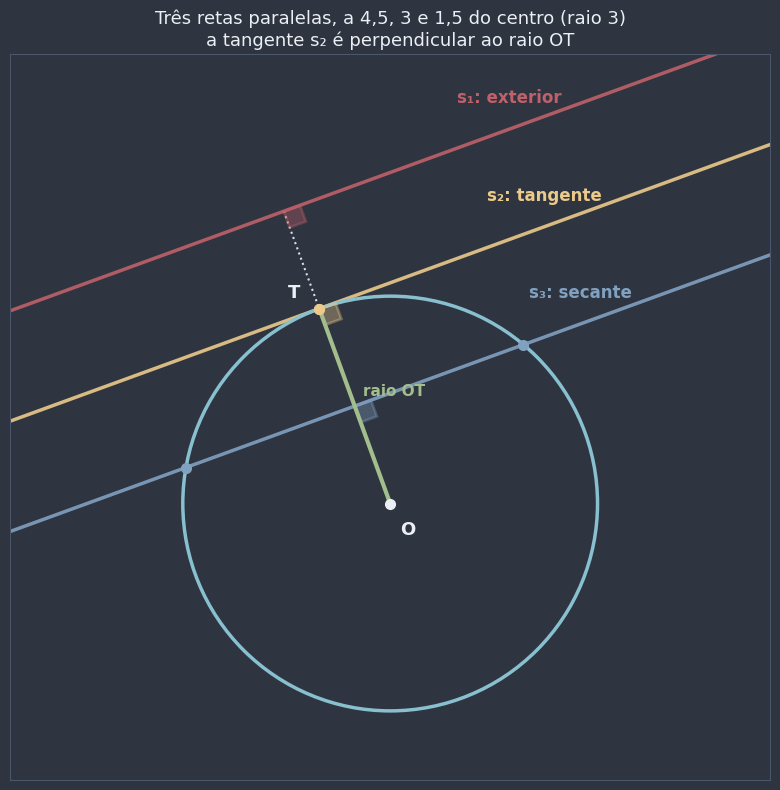

In [12]:
fig, ax = plt.subplots(figsize=(9, 8))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-5.5, -4), (5.5, 6.5)], margem=0)
desenhar_circunferencia(ax, O, r)
normal = direcao(inclinacao + 90)
ax.plot(*zip(O, O + 4.5 * normal), color=NORD_TEXTO_SEC, lw=1.5, linestyle=":", zorder=2)
for nome, (A_s, B_s) in retas.items():
    posicao = posicao_reta_circunferencia(O, r, A_s, B_s)
    cor = CORES_RETA[posicao]
    desenhar_reta(ax, A_s, B_s, cor=cor, largura=2.5)
    marcar_angulo_reto(ax, A_s, B_s, O, tamanho=0.25, cor=cor)
    ax.text(*(A_s + 3.6 * direcao(inclinacao) + 0.35 * normal), f"{nome}: {posicao}", color=cor, fontsize=12,
            fontweight="bold", ha="center")
    for P in intersecao_reta_circunferencia(O, r, A_s, B_s):
        desenhar_ponto(ax, P, cor=cor)
T = retas["s₂"][0]  # o ponto de tangência é o pé da perpendicular
ax.plot(*zip(O, T), color=COR_RAIO, lw=3, zorder=4)
rotular_segmento(ax, O, T, "raio OT", COR_RAIO, lado=-1, distancia=0.6)
desenhar_ponto(ax, T, "T", cor=CORES_RETA["tangente"], deslocamento=(-0.45, 0.15))
desenhar_ponto(ax, O, "O", cor=COR_CENTRO, deslocamento=(0.15, -0.45))
ax.set_title("Três retas paralelas, a 4,5, 3 e 1,5 do centro (raio 3)\n"
             "a tangente s₂ é perpendicular ao raio OT", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** o slider `distância` afasta a reta do centro (de 0 a $2r$, com $r = 3$), e o slider `giro` muda a direção. Observe a classificação e os pontos em comum. Pare **exatamente** em $d = 3$: a reta fica tangente, e o painel mede o ângulo entre o raio $\overline{OT}$ e a reta.

In [ ]:
def explorar_reta(distancia: float, giro: int) -> None:
    O_w, r_w = np.array([0.0, 0.0]), 3.0
    H = O_w + distancia * direcao(giro)  # o pé da perpendicular de O à reta
    A_w, B_w = H, H + direcao(giro + 90)  # dois pontos da reta
    posicao = posicao_reta_circunferencia(O_w, r_w, A_w, B_w)
    comuns = intersecao_reta_circunferencia(O_w, r_w, A_w, B_w)
    cor = CORES_RETA[posicao]

    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 6.6), gridspec_kw={"width_ratios": [1.15, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-6.5, -6.5), (6.5, 6.5)], margem=0)
    desenhar_circunferencia(ax, O_w, r_w)
    desenhar_reta(ax, A_w, B_w, cor=cor, largura=3)
    if distancia > 1e-9:
        ax.plot(*zip(O_w, H), color=NORD_TEXTO_SEC, lw=1.8, linestyle=":", zorder=3)
        rotular_segmento(ax, O_w, H, f"d = {distancia:.1f}", NORD_TEXTO_SEC, lado=1, distancia=0.7)
        marcar_angulo_reto(ax, H, B_w, O_w, tamanho=0.3, cor=NORD_TEXTO_SEC)
    itens = [
        ("d > r   →   exterior (nenhum ponto em comum)", posicao == "exterior"),
        ("d = r   →   tangente (um ponto em comum)", posicao == "tangente"),
        ("d < r   →   secante (dois pontos em comum)", posicao == "secante"),
    ]
    if posicao == "tangente":
        T = comuns[0]
        ax.plot(*zip(O_w, T), color=COR_RAIO, lw=3.5, zorder=4)
        marcar_angulo_reto(ax, T, B_w, O_w, tamanho=0.4, cor=COR_RAIO)
        desenhar_ponto(ax, T, "T", cor=cor)
        itens.append((f"ângulo entre o raio OT e a reta: {medir_angulo(T, O_w, B_w):.1f}°", True))
    elif posicao == "secante":
        P1, P2 = comuns
        ax.plot(*zip(P1, P2), color=COR_CORDA, lw=4, zorder=4)  # o pedaço da secante dentro é uma corda
        for P, nome in ((P1, "P₁"), (P2, "P₂")):
            desenhar_ponto(ax, P, nome, cor=cor)
        itens.append((f"a corda P₁P₂ mede {math.dist(P1, P2):.2f}", True))
    desenhar_ponto(ax, O_w, "O", cor=COR_CENTRO, deslocamento=(-0.5, -0.5))
    ax.set_title(f"d = {distancia:.1f} e r = {r_w:g}: reta {posicao}", color=cor, fontsize=14)
    escrever_checklist(ax_lista, itens, f"{len(comuns)} ponto(s) em comum")
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_reta,
    distancia=widgets.FloatSlider(value=3.0, min=0, max=6, step=0.1, description="distância:"),
    giro=widgets.IntSlider(value=60, min=0, max=180, step=15, description="giro:"),
);

interactive(children=(FloatSlider(value=3.0, description='distância:', max=6.0), IntSlider(value=60, descripti…

⚠️ **Erro comum:** achar que uma reta é tangente porque, **no desenho**, ela parece só "encostar" na circunferência. A definição não é visual: tangente é a reta com **um único** ponto em comum, e é por isso que o código decide pela **distância**, nunca pelo "olhômetro". Veja a reta abaixo, a uma distância 2,97 do centro de uma circunferência de raio 3. No desenho em tamanho normal, ela parece tangente; com uma lupa, aparecem os **dois** pontos em comum.

distância = 2.97  ->  secante, com 2 pontos em comum, a 0.85 um do outro


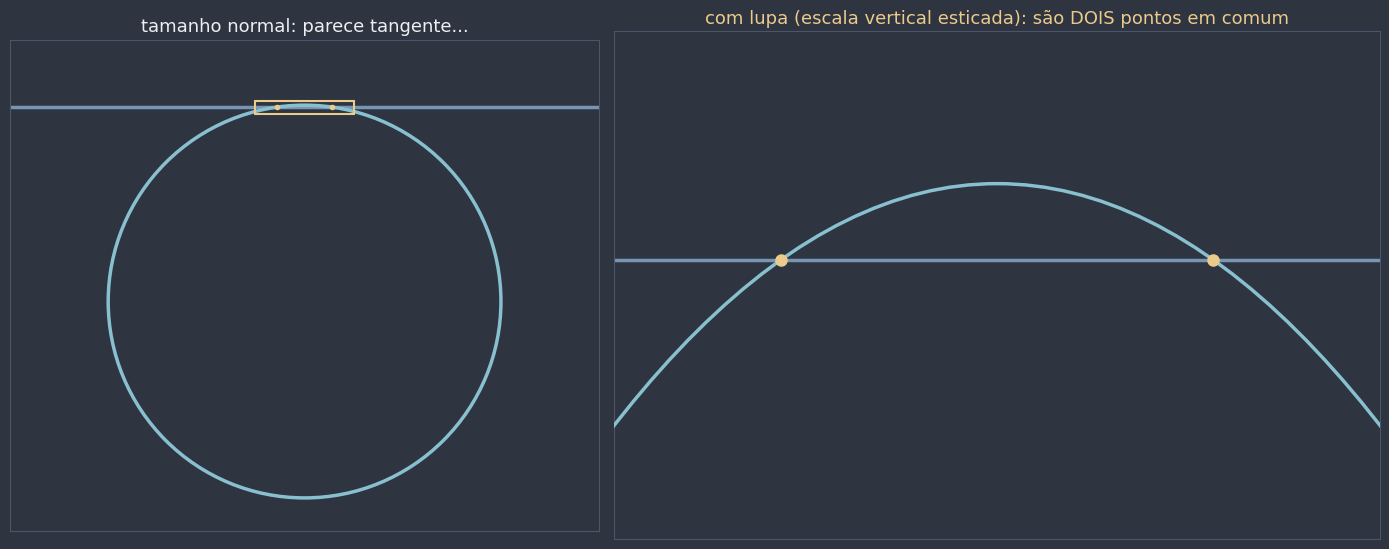

In [14]:
A_s, B_s = np.array([-5.0, 2.97]), np.array([5.0, 2.97])
comuns = intersecao_reta_circunferencia(O, r, A_s, B_s)
print(f"distância = {distancia_ponto_reta(O, A_s, 0):.2f}  ->  {posicao_reta_circunferencia(O, r, A_s, B_s)}, "
      f"com {len(comuns)} pontos em comum, a {math.dist(*comuns):.2f} um do outro")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [1, 1.3]})
fig.patch.set_facecolor(NORD_FUNDO)
for ax, limites, titulo in ((ax1, [(-4.5, -3.5), (4.5, 4)], "tamanho normal: parece tangente..."),
                            (ax2, [(-0.75, 2.86), (0.75, 3.06)],
                             "com lupa (escala vertical esticada): são DOIS pontos em comum")):
    preparar_eixo(ax, limites, margem=0)
    if ax is ax2:
        ax.set_aspect("auto")  # a lupa estica a vertical, para o vão entre a reta e o arco aparecer
    desenhar_circunferencia(ax, O, r)
    desenhar_reta(ax, A_s, B_s, cor=CORES_RETA["secante"], largura=2.5)
    for P in comuns:
        ax.plot(*P, "o", color=COR_AVISO, markersize=8 if ax is ax2 else 3, zorder=6)
    ax.set_title(titulo, color=NORD_TEXTO if ax is ax1 else COR_AVISO, fontsize=13)
ax1.add_patch(plt.Rectangle((-0.75, 2.86), 1.5, 0.2, fill=False, edgecolor=COR_AVISO, lw=1.5, zorder=7))
plt.tight_layout()
plt.show()

📎 **Conexão:** a reta tangente é o objeto central da seção 5 (segmentos tangentes) e volta em 📌 Ângulos na Circunferência, no ângulo formado por uma tangente e uma corda (o ângulo de segmento, ou semi-inscrito).

🎯 **Aplicação prática — rodas, trilhos e estradas:** uma roda apoiada no chão plano é uma circunferência **tangente** à reta do chão, e o ponto de contato fica exatamente embaixo do eixo, porque o raio até o ponto de contato é perpendicular ao chão (e é por isso que o peso do carro "desce" reto até o asfalto). Nas estradas e ferrovias, as curvas são projetadas como arcos de circunferência **tangentes** aos trechos retos (a chamada **concordância**): no ponto de tangência, a direção da reta e a da curva coincidem, e o carro ou o trem passa da reta para a curva sem um "bico" no caminho.

**Pergunta de checagem:** uma circunferência tem raio 5 cm, e uma reta está a 5 cm do centro. Quantos pontos em comum elas têm? E se a distância for 3 cm? E 8 cm?

**Pergunta de checagem:** uma reta $s$ é tangente a uma circunferência de centro $O$ no ponto $T$. Quanto mede o ângulo entre $\overline{OT}$ e $s$? Por que $T$ é o ponto de $s$ mais próximo de $O$?

## 4. Posições relativas de duas circunferências

Com duas circunferências, a comparação continua sendo com uma distância: agora, a **distância entre os centros**. Sejam $\lambda_1(O_1, r_1)$ e $\lambda_2(O_2, r_2)$, com $r_1 \geq r_2$, e seja $d = O_1O_2$. Imagine a segunda circunferência começando longe da primeira e se aproximando dela até os centros coincidirem. São seis casos:

| Posição | Condição | Pontos em comum |
|---|---|---|
| **exteriores** | $d > r_1 + r_2$ | 0 |
| **tangentes exteriores** | $d = r_1 + r_2$ | 1 |
| **secantes** | $r_1 - r_2 < d < r_1 + r_2$ | 2 |
| **tangentes interiores** | $d = r_1 - r_2$ | 1 |
| **interiores** | $d < r_1 - r_2$ | 0 |
| **concêntricas** | $d = 0$ | 0 |

As concêntricas são um caso particular das interiores, em que os centros coincidem (com raios iguais, as duas circunferências seriam a mesma: **coincidentes**). Nas tangentes **exteriores**, cada circunferência fica de um lado da reta tangente comum no ponto de contato; nas tangentes **interiores**, uma fica dentro da outra, encostando por dentro.

**De onde vêm essas condições?** Da **desigualdade triangular** de [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb). Se as circunferências são **secantes** e $P$ é um ponto comum, então $O_1P = r_1$ e $O_2P = r_2$, e o triângulo $O_1O_2P$ tem lados $r_1$, $r_2$ e $d$. Um triângulo com esses lados existe exatamente quando

$$r_1 - r_2 < d < r_1 + r_2.$$

Nos dois casos-limite, $d = r_1 + r_2$ e $d = r_1 - r_2$, o "triângulo" fica achatado: $O_1$, $O_2$ e $P$ ficam **alinhados**. Por isso, **nas tangentes, o ponto de tangência está sobre a reta dos centros** $\overleftrightarrow{O_1O_2}$.

**No código:** a função `posicao_circunferencias(O1, r1, O2, r2)` aplica a tabela (ela mesma descobre qual raio é o maior, então a ordem das circunferências não importa), e `intersecao_circunferencias` devolve os pontos em comum. A tabela abaixo testa um exemplo de cada caso, com $r_1 = 4$ e $r_2 = 2$:

In [16]:
def posicao_circunferencias(O1, r1: float, O2, r2: float) -> str:
    """Posição relativa de λ(O1, r1) e λ(O2, r2), comparando a distância d = O1O2 entre os centros com a
    soma e a diferença dos raios. A ordem das duas circunferências não importa."""
    d = math.dist(O1, O2)
    maior, menor = max(r1, r2), min(r1, r2)
    if iguais(d, 0):
        return "coincidentes" if iguais(r1, r2) else "concêntricas"
    if iguais(d, maior + menor):
        return "tangentes exteriores"
    if iguais(d, maior - menor):
        return "tangentes interiores"
    if d > maior + menor:
        return "exteriores"
    if d < maior - menor:
        return "interiores"
    return "secantes"


def intersecao_circunferencias(O1, r1: float, O2, r2: float) -> list[np.ndarray]:
    """Pontos comuns de λ(O1, r1) e λ(O2, r2): nenhum, um (tangentes) ou dois (secantes).

    Os pontos comuns ficam simétricos em relação à reta dos centros, sobre a perpendicular a ela num
    ponto H. A distância a = O1H sai de aplicar Pitágoras nos triângulos retângulos O1HP e O2HP
    (📌 Triângulos Retângulos e 📌 Geometria Analítica); aqui só usamos a conta para desenhar e conferir.
    """
    posicao = posicao_circunferencias(O1, r1, O2, r2)
    if posicao not in ("secantes", "tangentes exteriores", "tangentes interiores"):
        return []
    O1, O2 = np.asarray(O1, dtype=float), np.asarray(O2, dtype=float)
    d = math.dist(O1, O2)
    u = (O2 - O1) / d  # direção da reta dos centros
    a = (d**2 + r1**2 - r2**2) / (2 * d)
    H = O1 + a * u
    if posicao != "secantes":
        return [H]  # nas tangentes, o ponto comum está SOBRE a reta dos centros
    h = math.sqrt(max(r1**2 - a**2, 0.0))
    normal = np.array([-u[1], u[0]])
    return [H + h * normal, H - h * normal]



r1, r2 = 4.0, 2.0
O1 = np.array([0.0, 0.0])
distancias_exemplo = [8.0, 6.0, 4.0, 2.0, 1.0, 0.0]

linhas = []
for d in distancias_exemplo:
    O2 = np.array([d, 0.0])
    linhas.append({"d": d, "r₁ + r₂": r1 + r2, "r₁ − r₂": r1 - r2,
                   "posição": posicao_circunferencias(O1, r1, O2, r2),
                   "pontos em comum": len(intersecao_circunferencias(O1, r1, O2, r2))})
display(pd.DataFrame(linhas).style.hide(axis="index"))

d,r₁ + r₂,r₁ − r₂,posição,pontos em comum
8.000000,6.000000,2.000000,exteriores,0
6.000000,6.000000,2.000000,tangentes exteriores,1
4.000000,6.000000,2.000000,secantes,2
2.000000,6.000000,2.000000,tangentes interiores,1
1.000000,6.000000,2.000000,interiores,0
0.000000,6.000000,2.000000,concêntricas,0


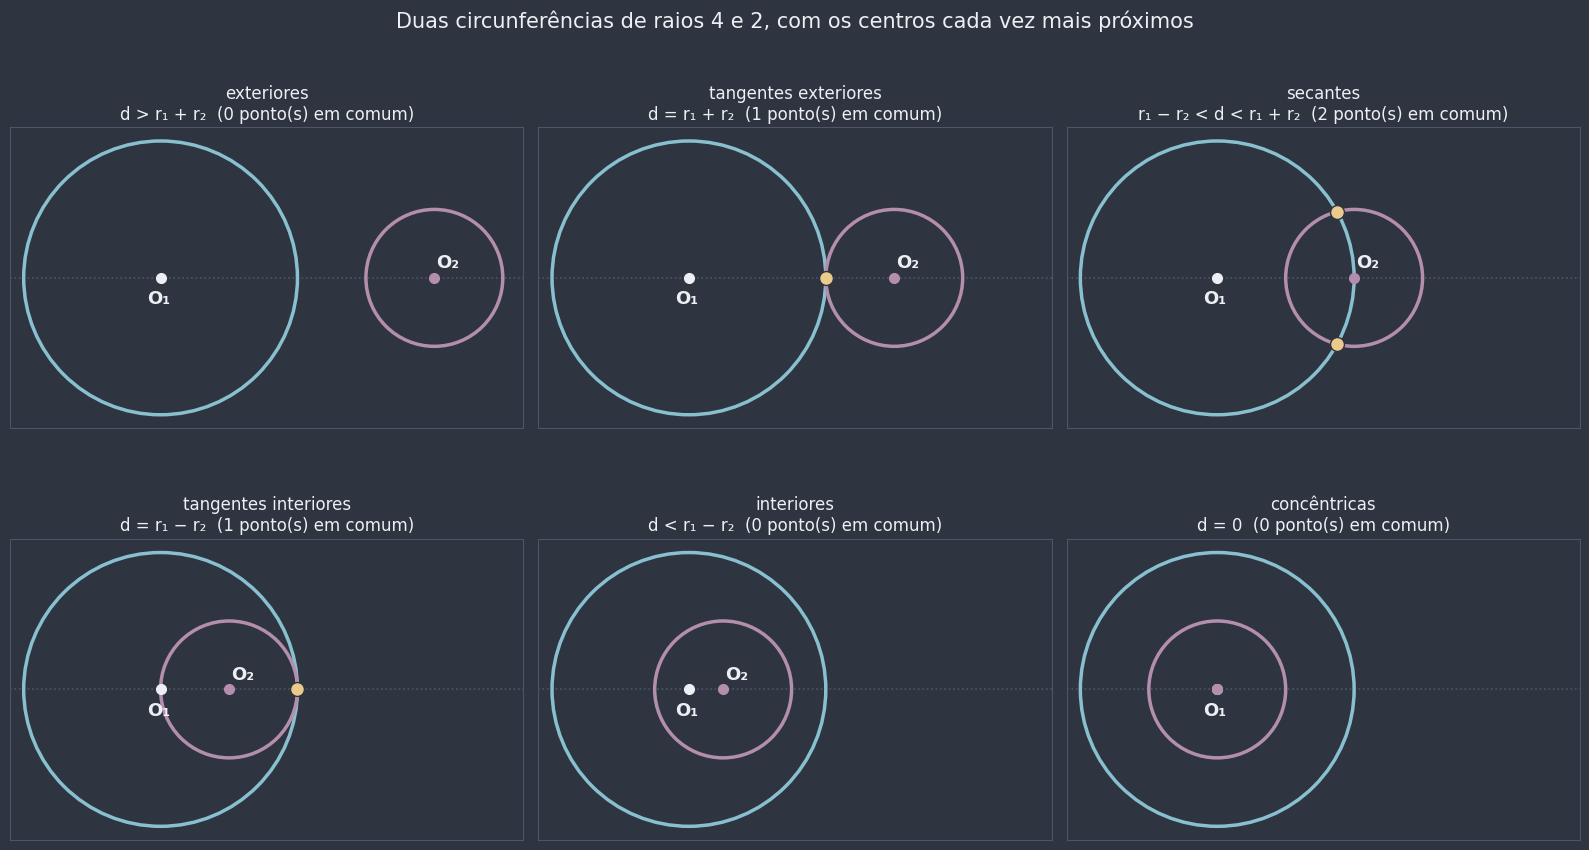

In [17]:
CONDICOES = {
    "exteriores": "d > r₁ + r₂", "tangentes exteriores": "d = r₁ + r₂", "secantes": "r₁ − r₂ < d < r₁ + r₂",
    "tangentes interiores": "d = r₁ − r₂", "interiores": "d < r₁ − r₂", "concêntricas": "d = 0",
}

fig, eixos = plt.subplots(2, 3, figsize=(16, 9.5))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, d in zip(eixos.flat, distancias_exemplo):
    O2 = np.array([d, 0.0])
    posicao = posicao_circunferencias(O1, r1, O2, r2)
    comuns = intersecao_circunferencias(O1, r1, O2, r2)
    preparar_eixo(ax, [(-r1, -r1), (10.2, r1)], margem=0.4)
    ax.axhline(0, color=NORD_LINHA, lw=1.2, linestyle=":", zorder=1)  # a reta dos centros
    desenhar_circunferencia(ax, O1, r1)
    desenhar_circunferencia(ax, O2, r2, cor=COR_CIRCUNFERENCIA_2)
    desenhar_ponto(ax, O1, "O₁", cor=COR_CENTRO, deslocamento=(-0.4, -0.75))
    desenhar_ponto(ax, O2, "O₂" if d > 0 else "", cor=COR_CIRCUNFERENCIA_2, deslocamento=(0.05, 0.3))
    for P in comuns:
        ax.plot(*P, "o", color=COR_AVISO, markersize=10, markeredgecolor=NORD_FUNDO, zorder=7)
    ax.set_title(f"{posicao}\n{CONDICOES[posicao]}  ({len(comuns)} ponto(s) em comum)", color=NORD_TEXTO,
                 fontsize=12)
fig.suptitle("Duas circunferências de raios 4 e 2, com os centros cada vez mais próximos", color=NORD_TEXTO,
             fontsize=15)
plt.tight_layout()
plt.show()

Nos dois casos de tangência, o ponto amarelo está **sobre** a reta dos centros (pontilhada), como a desigualdade triangular previu.

🕹️ **Widget interativo:** a circunferência azul (raio 4) fica parada; o slider `distância` move o centro $O_2$ da lilás, e o slider `r2` muda o raio dela. Faça a lilás atravessar a azul de fora para dentro e passe pelos seis casos. No caso **secante**, aparece o triângulo $O_1O_2P$ de lados $r_1$, $r_2$ e $d$. Tente deixar o triângulo bem "achatado" e veja o que acontece com a classificação.

In [ ]:
def explorar_duas_circunferencias(distancia: float, r2: float) -> None:
    O1_w, r1_w = np.array([0.0, 0.0]), 4.0
    O2_w = np.array([distancia, 0.0])
    posicao = posicao_circunferencias(O1_w, r1_w, O2_w, r2)
    comuns = intersecao_circunferencias(O1_w, r1_w, O2_w, r2)

    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(15, 6.2), gridspec_kw={"width_ratios": [1.45, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-r1_w, -r1_w), (14.2, r1_w)], margem=0.4)
    ax.axhline(0, color=NORD_LINHA, lw=1.2, linestyle=":", zorder=1)
    desenhar_circunferencia(ax, O1_w, r1_w)
    desenhar_circunferencia(ax, O2_w, r2, cor=COR_CIRCUNFERENCIA_2)
    if posicao == "secantes":
        P = comuns[0]
        ax.add_patch(Polygon([O1_w, O2_w, P], closed=True, facecolor=COR_AVISO, alpha=0.12, edgecolor="none"))
        for X, Y, texto, cor in ((O1_w, P, "r₁", COR_CIRCUNFERENCIA), (O2_w, P, "r₂", COR_CIRCUNFERENCIA_2)):
            ax.plot(*zip(X, Y), color=cor, lw=2.2, linestyle="--", zorder=4)
            rotular_segmento(ax, X, Y, texto, cor, lado=1 if X is O1_w else -1, distancia=0.35, tamanho=13)
        ax.text(distancia / 2, -0.45, "d", color=COR_AVISO, fontsize=13, fontweight="bold", ha="center")
    for P in comuns:
        ax.plot(*P, "o", color=COR_AVISO, markersize=10, markeredgecolor=NORD_FUNDO, zorder=7)
    desenhar_ponto(ax, O1_w, "O₁", cor=COR_CENTRO, deslocamento=(-0.5, -0.8))
    desenhar_ponto(ax, O2_w, "O₂" if distancia > 0 else "", cor=COR_CIRCUNFERENCIA_2, deslocamento=(0.1, 0.3))
    ax.set_title(f"d = {distancia:.1f},  r₁ = {r1_w:g},  r₂ = {r2:g}:  {posicao}", color=COR_AVISO, fontsize=14)
    maior, menor = max(r1_w, r2), min(r1_w, r2)
    itens = [(f"{nome}:  {CONDICOES[nome]}", posicao == nome) for nome in CONDICOES]
    if posicao == "coincidentes":
        itens.append(("coincidentes: mesmo centro e mesmo raio", True))
    escrever_checklist(ax_lista, itens, f"r₁ + r₂ = {maior + menor:g}    r₁ − r₂ = {maior - menor:g}    "
                                         f"({len(comuns)} ponto(s) em comum)")
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_duas_circunferencias,
    distancia=widgets.FloatSlider(value=5.0, min=0, max=10, step=0.1, description="distância:"),
    r2=widgets.FloatSlider(value=2.5, min=0.5, max=4, step=0.5, description="r2:"),
);

interactive(children=(FloatSlider(value=5.0, description='distância:', max=10.0), FloatSlider(value=2.5, descr…

💡 **Dica:** para lembrar a tabela, pense na circunferência menor **viajando** em direção à maior: de longe (exteriores), ela **encosta por fora** ($d = r_1 + r_2$), **atravessa** a borda (secantes), **encosta por dentro** ($d = r_1 - r_2$), fica **solta lá dentro** (interiores) e, no fim, **centraliza** (concêntricas). A tabela completa está no resumo, no fim do notebook.

🎯 **Aplicação prática — engrenagens e correias:** duas engrenagens que giram juntas têm as suas **circunferências primitivas** (as circunferências "de contato" das duas rodas dentadas) **tangentes exteriores**; o ponto de tangência fica sobre a reta dos eixos, e as duas rodas giram em sentidos contrários. Numa **engrenagem interna** (um anel com dentes por dentro, como nas engrenagens planetárias dos câmbios automáticos e das bicicletas com marchas no cubo), a roda pequena gira **dentro** da grande, e as primitivas são **tangentes interiores**: aí as duas giram no mesmo sentido. Já nas **polias ligadas por correia** (como a corrente da bicicleta), a correia segue retas **tangentes às duas circunferências ao mesmo tempo**, as tangentes comuns que aparecem no Desafio 7.

🕵️ **Curiosidade histórica:** quase tudo deste notebook já estava no **Livro III dos *Elementos* de Euclides**, escrito por volta de 300 a.C. e dedicado inteiramente à circunferência. Lá estão, entre outras, a propriedade de que o diâmetro perpendicular a uma corda a divide ao meio, a de que o diâmetro é a maior corda, a de que a tangente é perpendicular ao raio e a de que, em duas circunferências tangentes, a reta dos centros passa pelo ponto de contato. Mais de 2 300 anos depois, ainda se aprendem essas propriedades com as mesmas justificativas.

📖 **Leitura complementar:** [Engrenagem](https://pt.wikipedia.org/wiki/Engrenagem)

**Pergunta de checagem:** duas circunferências de raios 8 cm e 3 cm têm os centros a 5 cm um do outro. Qual é a posição relativa delas? E se a distância entre os centros fosse 11 cm?

**Pergunta de checagem:** duas circunferências de raios 5 cm e 3 cm são secantes. Entre quais valores pode estar a distância entre os centros? Que triângulo explica esses limites?

## 5. Segmentos tangentes e quadriláteros circunscritíveis

Por um ponto **sobre** a circunferência passa uma única reta tangente (a perpendicular ao raio naquele ponto). Por um ponto **interior**, nenhuma: toda reta por ele é secante. E por um ponto $P$ **exterior** passam exatamente **duas** retas tangentes. Se $A$ e $B$ são os pontos de tangência, os segmentos $\overline{PA}$ e $\overline{PB}$ são os **segmentos tangentes** traçados de $P$.

📌 **Teorema (segmentos tangentes):** os dois segmentos tangentes traçados de um mesmo ponto exterior são **congruentes**: $PA = PB$.

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $O\hat{A}P = O\hat{B}P = 90^\circ$ | a tangente é perpendicular ao raio (seção 3) |
| 2 | $OA = OB$ | são raios |
| 3 | $OP = OP$ | lado comum, a hipotenusa dos dois triângulos retângulos |
| 4 | $\triangle OAP \equiv \triangle OBP$ | caso especial **hipotenusa-cateto** dos triângulos retângulos (passos 1, 2 e 3; Exercício Intermediário 4 de [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb)) |
| 5 | $PA = PB$ | lados correspondentes de triângulos congruentes ∎ |

A congruência dá ainda mais duas consequências:
- $A\hat{P}O = B\hat{P}O$: **$\overline{OP}$ está sobre a bissetriz do ângulo $A\hat{P}B$**. Faz sentido: $O$ está à mesma distância $r$ dos dois lados do ângulo, e a bissetriz é o lugar geométrico desses pontos ([`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb)).
- $P$ e $O$ estão, cada um, à mesma distância de $A$ e de $B$ ($PA = PB$ e $OA = OB$), então os dois estão na **mediatriz** de $\overline{AB}$: **a reta $OP$ é a mediatriz da corda $\overline{AB}$** ([`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb)).

**No código:** como encontrar $A$ e $B$? Como $O\hat{A}P$ é reto, o triângulo $OAP$ é retângulo com hipotenusa $\overline{OP}$, e em [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb) você viu que o circuncentro de um triângulo retângulo é o **ponto médio da hipotenusa**. Então $A$ (e também $B$) está na circunferência de **diâmetro** $\overline{OP}$. Os pontos de tangência são os pontos comuns de $\lambda(O, r)$ com essa circunferência, e a função `intersecao_circunferencias` da seção 4 já sabe calculá-los.

In [19]:
def pontos_de_tangencia(P, O, r: float) -> list[np.ndarray]:
    """Pontos de tangência das retas tangentes à circunferência λ(O, r) traçadas por P.

    Se A é um ponto de tangência, o ângulo OÂP é reto (a tangente é perpendicular ao raio). Num
    triângulo retângulo, o circuncentro é o ponto médio da hipotenusa (0410a): então A está na
    circunferência de diâmetro OP. Os pontos de tangência são os pontos comuns de λ(O, r) com essa
    circunferência. P exterior: 2 pontos; P sobre λ: 1 (o próprio P); P interior: nenhum.
    """
    return intersecao_circunferencias(O, r, ponto_medio(O, P), math.dist(O, P) / 2)



O, r = np.array([0.0, 0.0]), 3.0
P = np.array([7.0, 2.0])
A, B = pontos_de_tangencia(P, O, r)
M_AB = ponto_medio(A, B)

medidas = {
    "PA": math.dist(P, A), "PB": math.dist(P, B),
    "ângulo OÂP": medir_angulo(A, O, P), "ângulo OB̂P": medir_angulo(B, O, P),
    "ângulo AP̂O": medir_angulo(P, A, O), "ângulo BP̂O": medir_angulo(P, B, O),
    "ângulo entre OP e AB": medir_angulo(M_AB, P, A),
    "distância de M (meio de AB) à reta OP": distancia_ponto_reta(M_AB, O, direcao_de(O, P)),
}
display(pd.DataFrame({"medida": list(medidas), "valor": [f"{v:.4f}" for v in medidas.values()]})
        .style.hide(axis="index"))

medida,valor
PA,6.6332
PB,6.6332
ângulo OÂP,90.0000
ângulo OB̂P,90.0000
ângulo AP̂O,24.3357
ângulo BP̂O,24.3357
ângulo entre OP e AB,90.0000
distância de M (meio de AB) à reta OP,0.0000


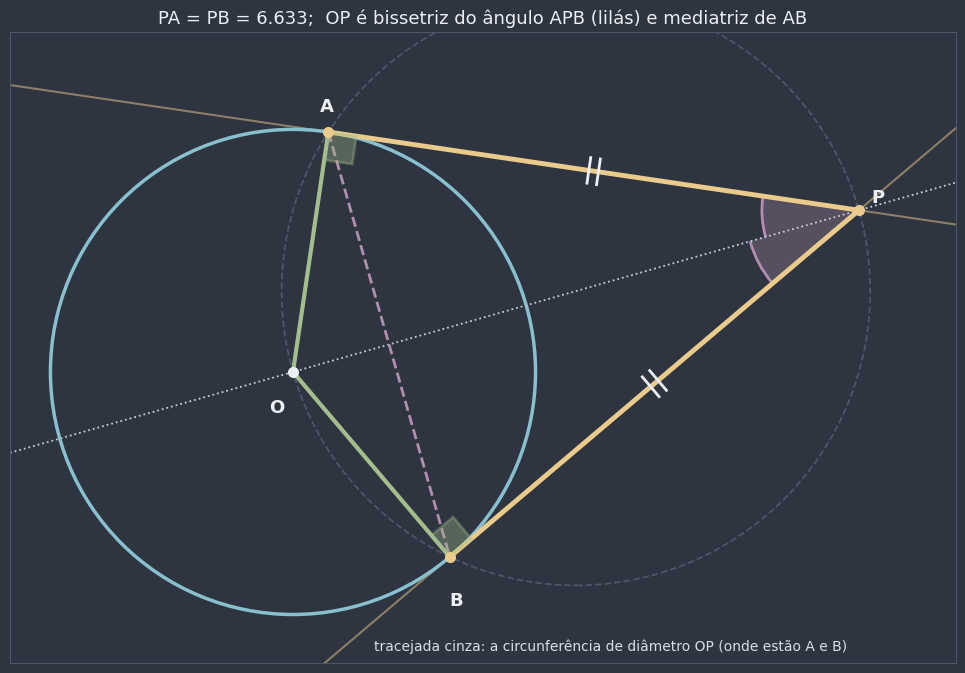

In [20]:
fig, ax = plt.subplots(figsize=(10, 6.8))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-3.5, -3.6), (8.2, 4.2)], margem=0)
desenhar_circunferencia(ax, ponto_medio(O, P), math.dist(O, P) / 2, cor=NORD_LINHA, estilo="--", largura=1.3)
desenhar_circunferencia(ax, O, r)
desenhar_reta(ax, O, P, cor=NORD_TEXTO_SEC, estilo=":", largura=1.3)
for T in (A, B):
    desenhar_reta(ax, P, T, cor=CORES_RETA["tangente"], largura=1.5, alpha=0.5)
    ax.plot(*zip(P, T), color=CORES_RETA["tangente"], lw=3.5, zorder=4)
    ax.plot(*zip(O, T), color=COR_RAIO, lw=3, zorder=4)
    marcar_angulo_reto(ax, T, O, P, tamanho=0.35, cor=COR_RAIO)
    marcar_congruentes(ax, P, T, tracos=2)
ax.plot(*zip(A, B), color=COR_CORDA, lw=2, linestyle="--", zorder=3)
desenhar_arco(ax, P, A, O, raio=1.2, cor=COR_EXTRA, marcar_reto=False)
desenhar_arco(ax, P, O, B, raio=1.4, cor=COR_EXTRA, marcar_reto=False)
desenhar_ponto(ax, O, "O", cor=COR_CENTRO, deslocamento=(-0.3, -0.5))
desenhar_ponto(ax, P, "P", cor=COR_AVISO, deslocamento=(0.15, 0.1))
desenhar_ponto(ax, A, "A", cor=COR_AVISO, deslocamento=(-0.1, 0.25))
desenhar_ponto(ax, B, "B", cor=COR_AVISO, deslocamento=(0.0, -0.6))
ax.text(1.0, -3.45, "tracejada cinza: a circunferência de diâmetro OP (onde estão A e B)", color=NORD_TEXTO_SEC,
        fontsize=10)
ax.set_title(f"PA = PB = {math.dist(P, A):.3f};  OP é bissetriz do ângulo APB (lilás) e mediatriz de AB",
             color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** mova o ponto $P$ com os sliders `x de P` e `y de P`. As duas tangentes e os comprimentos $PA$ e $PB$ são recalculados a cada posição. Tente encontrar uma posição em que $PA \neq PB$ (não vai conseguir!). E leve $P$ para **dentro** da circunferência: o que acontece com as tangentes?

In [21]:
def explorar_tangentes(x_P: float, y_P: float) -> None:
    O_w, r_w = np.array([0.0, 0.0]), 3.0
    P_w = np.array([x_P, y_P])
    posicao = posicao_ponto(P_w, O_w, r_w)
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 6.4), gridspec_kw={"width_ratios": [1.25, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-8.5, -8.5), (8.5, 8.5)], margem=0)
    desenhar_circunferencia(ax, O_w, r_w)
    if posicao == "exterior":
        A_w, B_w = pontos_de_tangencia(P_w, O_w, r_w)
        ax.plot(*zip(O_w, P_w), color=NORD_TEXTO_SEC, lw=1.3, linestyle=":")
        for T, nome in ((A_w, "A"), (B_w, "B")):
            desenhar_reta(ax, P_w, T, cor=CORES_RETA["tangente"], largura=1.5, alpha=0.5)
            ax.plot(*zip(P_w, T), color=CORES_RETA["tangente"], lw=3.5, zorder=4)
            ax.plot(*zip(O_w, T), color=COR_RAIO, lw=2.5, zorder=4)
            marcar_angulo_reto(ax, T, O_w, P_w, tamanho=0.45, cor=COR_RAIO)
            marcar_congruentes(ax, P_w, T, tracos=2, tamanho=0.25)
            desenhar_ponto(ax, T, nome, cor=COR_AVISO)
        PA, PB = math.dist(P_w, A_w), math.dist(P_w, B_w)
        itens = [
            (f"PA = {PA:.3f}", True), (f"PB = {PB:.3f}", True), ("PA = PB", iguais(PA, PB)),
            (f"∠OAP = {medir_angulo(A_w, O_w, P_w):.1f}°  e  ∠OBP = {medir_angulo(B_w, O_w, P_w):.1f}°", True),
            (f"∠APO = {medir_angulo(P_w, A_w, O_w):.2f}°  e  ∠BPO = {medir_angulo(P_w, B_w, O_w):.2f}°",
             iguais(medir_angulo(P_w, A_w, O_w), medir_angulo(P_w, B_w, O_w))),
        ]
        titulo, cor = "P exterior: duas tangentes, com PA = PB", COR_DESTAQUE
    elif posicao == "sobre a circunferência":
        desenhar_reta(ax, P_w, P_w + direcao(direcao_de(O_w, P_w) + 90), cor=CORES_RETA["tangente"], largura=2.5)
        ax.plot(*zip(O_w, P_w), color=COR_RAIO, lw=2.5)
        itens = [("P está sobre a circunferência:", True), ("uma única tangente, perpendicular ao raio OP", True)]
        titulo, cor = "P sobre a circunferência: uma única tangente", COR_AVISO
    else:
        itens = [("P é interior:", False), ("toda reta que passa por P é secante", False),
                 ("não há tangentes por P", False)]
        titulo, cor = "P interior: nenhuma reta tangente passa por P", COR_ALERTA
    desenhar_ponto(ax, O_w, "O", cor=COR_CENTRO, deslocamento=(-0.6, -0.7))
    desenhar_ponto(ax, P_w, "P", cor=COR_AVISO)
    ax.set_title(titulo, color=cor, fontsize=14)
    escrever_checklist(ax_lista, itens, f"OP = {math.dist(O_w, P_w):.2f}   e   r = {r_w:g}")
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_tangentes,
    x_P=widgets.FloatSlider(value=6.0, min=-8, max=8, step=0.5, description="x de P:"),
    y_P=widgets.FloatSlider(value=3.0, min=-8, max=8, step=0.5, description="y de P:"),
);

interactive(children=(FloatSlider(value=6.0, description='x de P:', max=8.0, min=-8.0, step=0.5), FloatSlider(…

### Quadriláteros circunscritíveis e o teorema de Pitot

Um polígono é **circunscrito** a uma circunferência quando **todos os seus lados são tangentes** a ela; a circunferência, então, está **inscrita** no polígono. Um quadrilátero que admite uma circunferência inscrita (tangente aos quatro lados) é chamado de **circunscritível**. Você já conhece o caso do triângulo: a circunferência inscrita de [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb), com centro no incentro. Mas nem todo quadrilátero é circunscritível; o teste é surpreendentemente simples.

📌 **Teorema de Pitot:** num quadrilátero convexo circunscritível $ABCD$, **a soma de dois lados opostos é igual à soma dos outros dois**:

$$AB + CD = BC + DA.$$

**Por quê?** De cada vértice saem **dois segmentos tangentes** até os pontos de tangência dos lados vizinhos, e eles são **congruentes** (o teorema que acabamos de ver). Chame de $a$ os dois segmentos que saem de $A$, de $b$ os que saem de $B$, de $c$ os de $C$ e de $d$ os de $D$. Cada lado é formado por dois desses segmentos, um de cada ponta:

$$AB = a + b, \quad BC = b + c, \quad CD = c + d, \quad DA = d + a.$$

Então $AB + CD = a + b + c + d$ e $BC + DA = b + c + d + a$: as duas somas são iguais. A **recíproca** também vale para quadriláteros convexos (se $AB + CD = BC + DA$, então existe uma circunferência tangente aos quatro lados), mas a demonstração dela fica de fora deste notebook.

**No código:** a função `quadrilatero_circunscrito` constrói um quadrilátero ao contrário: escolhe quatro pontos de tangência na circunferência, traça as quatro tangentes (cada uma perpendicular ao raio, como na seção 3) e pega os cruzamentos de tangentes vizinhas como vértices.

In [22]:
def quadrilatero_circunscrito(O, r: float, angulos_tangencia) -> tuple[list[np.ndarray], list[np.ndarray]]:
    """Quadrilátero formado pelas quatro retas tangentes a λ(O, r) nos pontos das direções
    `angulos_tangencia` (em graus, em ordem crescente, com dois pontos vizinhos a menos de 180° um do outro,
    para que as tangentes vizinhas se cruzem).

    A tangente no ponto de direção α é perpendicular ao raio, então tem inclinação α + 90°.
    Devolve (vertices, tangencias): o vértice k é o cruzamento das tangentes nos pontos k e k + 1.
    """
    T = [ponto_na_circunferencia(O, r, a) for a in angulos_tangencia]
    vertices = [cruzamento(T[k], angulos_tangencia[k] + 90, T[(k + 1) % 4], angulos_tangencia[(k + 1) % 4] + 90)
                for k in range(4)]
    return vertices, T


def lados_do_quadrilatero(vertices) -> list[float]:
    """Medidas AB, BC, CD e DA do quadrilátero ABCD."""
    return [math.dist(vertices[k], vertices[(k + 1) % 4]) for k in range(4)]



O, r = np.array([0.0, 0.0]), 2.0
vertices, tangencias = quadrilatero_circunscrito(O, r, [10, 100, 215, 290])
AB, BC, CD, DA = lados_do_quadrilatero(vertices)

# O vértice k fica entre os pontos de tangência k e k + 1: os dois segmentos tangentes dele
display(pd.DataFrame([
    {"vértice": nome, "segmento tangente 1": f"{math.dist(V, tangencias[k]):.4f}",
     "segmento tangente 2": f"{math.dist(V, tangencias[(k + 1) % 4]):.4f}"}
    for k, (V, nome) in enumerate(zip(vertices, "ABCD"))
]).style.hide(axis="index"))
print(f"AB + CD = {AB:.4f} + {CD:.4f} = {AB + CD:.4f}")
print(f"BC + DA = {BC:.4f} + {DA:.4f} = {BC + DA:.4f}")

vértice,segmento tangente 1,segmento tangente 2
A,2.0000,2.0000
B,3.1394,3.1394
C,1.5347,1.5347
D,1.6782,1.6782


AB + CD = 5.1394 + 3.2129 = 8.3522
BC + DA = 4.6740 + 3.6782 = 8.3522


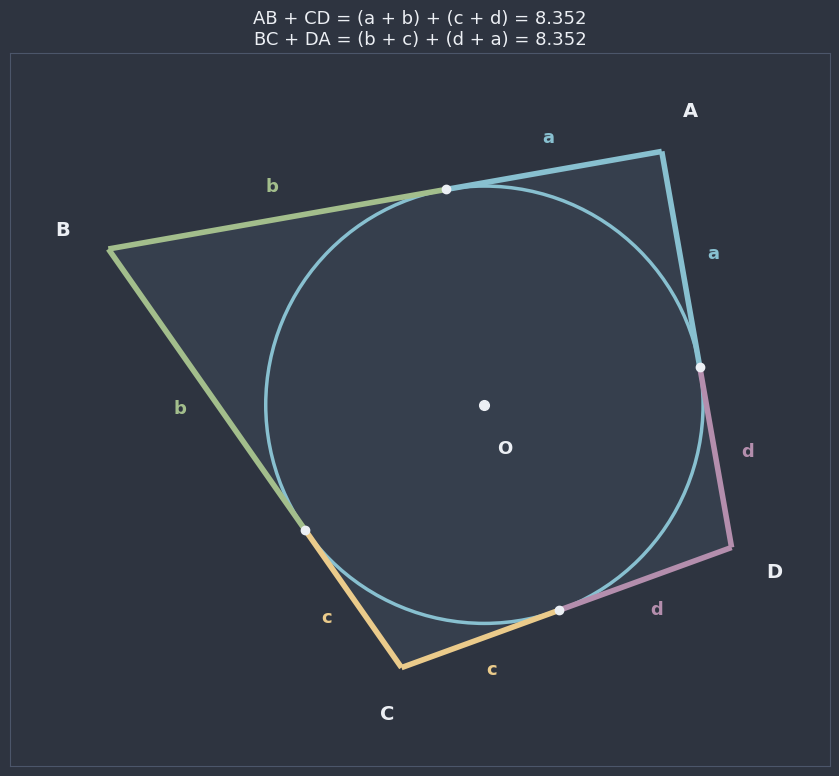

In [23]:
CORES_VERTICES = [COR_PONTO, COR_DESTAQUE, COR_AVISO, COR_EXTRA]


def desenhar_pitot(ax, vertices, tangencias, O, r: float) -> None:
    """Desenha o quadrilátero circunscrito, a circunferência inscrita e os segmentos tangentes, pintando
    os dois segmentos que saem de um mesmo vértice com a mesma cor (e a mesma letra minúscula)."""
    ax.add_patch(Polygon(vertices, closed=True, facecolor=COR_SECUNDARIA, alpha=0.1, edgecolor="none"))
    desenhar_circunferencia(ax, O, r)
    for k, (V, nome) in enumerate(zip(vertices, "ABCD")):
        for T in (tangencias[k], tangencias[(k + 1) % 4]):
            ax.plot(*zip(V, T), color=CORES_VERTICES[k], lw=4, solid_capstyle="butt", zorder=4)
            rotular_segmento(ax, V, T, nome.lower(), CORES_VERTICES[k], lado=1 if T is tangencias[k] else -1,
                             distancia=0.3, tamanho=13)
        rotular_fora(ax, V, nome, O, distancia=0.45, tamanho=14)
    for T in tangencias:
        ax.plot(*T, "o", color=NORD_TEXTO, markersize=6, zorder=6)
    desenhar_ponto(ax, O, "O", cor=COR_CENTRO, deslocamento=(0.12, -0.45))


fig, ax = plt.subplots(figsize=(8.5, 8))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, vertices, margem=0.9)
desenhar_pitot(ax, vertices, tangencias, O, r)
ax.set_title(f"AB + CD = (a + b) + (c + d) = {AB + CD:.3f}\nBC + DA = (b + c) + (d + a) = {BC + DA:.3f}",
             color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** cada slider move um dos quatro pontos de tangência sobre a circunferência (de raio 2). O quadrilátero muda de forma, os lados mudam de tamanho, mas o painel mostra que $AB + CD$ e $BC + DA$ continuam sempre iguais. Experimente deixar dois pontos de tangência vizinhos bem afastados (perto de 170°) e veja o vértice entre eles ir para longe.

In [ ]:
def explorar_pitot(t1: int, t2: int, t3: int, t4: int) -> None:
    O_w, r_w = np.array([0.0, 0.0]), 2.0
    vertices_w, tangencias_w = quadrilatero_circunscrito(O_w, r_w, [t1, t2, t3, t4])
    AB_w, BC_w, CD_w, DA_w = lados_do_quadrilatero(vertices_w)
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 6.6), gridspec_kw={"width_ratios": [1.2, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, vertices_w, margem=0.9)
    desenhar_pitot(ax, vertices_w, tangencias_w, O_w, r_w)
    ax.set_title("Quadrilátero ABCD circunscrito à circunferência", color=NORD_TEXTO, fontsize=13)
    itens = [
        (f"AB = {AB_w:.2f}   BC = {BC_w:.2f}   CD = {CD_w:.2f}   DA = {DA_w:.2f}", True),
        (f"AB + CD = {AB_w + CD_w:.3f}", True),
        (f"BC + DA = {BC_w + DA_w:.3f}", True),
        ("AB + CD = BC + DA  (Pitot)", iguais(AB_w + CD_w, BC_w + DA_w)),
    ]
    escrever_checklist(ax_lista, itens, "Teorema de Pitot")
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_pitot,
    t1=widgets.IntSlider(value=10, min=0, max=80, step=5, description="T₁ (°):"),
    t2=widgets.IntSlider(value=100, min=90, max=170, step=5, description="T₂ (°):"),
    t3=widgets.IntSlider(value=215, min=180, max=260, step=5, description="T₃ (°):"),
    t4=widgets.IntSlider(value=290, min=270, max=350, step=5, description="T₄ (°):"),
);

interactive(children=(IntSlider(value=10, description='T₁ (°):', max=80, step=5), IntSlider(value=100, descrip…

⚠️ **Erro comum:** aplicar a igualdade de Pitot a **qualquer** quadrilátero. Ela só vale para os **circunscritíveis**, e serve justamente para reconhecê-los. Veja alguns quadriláteros conhecidos de [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb) e [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb), testados pela igualdade (com a recíproca de Pitot, quem passa no teste admite uma circunferência inscrita):

In [25]:
def satisfaz_pitot(AB: float, BC: float, CD: float, DA: float) -> bool:
    """True se as somas dos lados opostos são iguais (AB + CD = BC + DA)."""
    return iguais(AB + CD, BC + DA)


exemplos = {
    "retângulo 6 × 3": (6, 3, 6, 3),
    "quadrado de lado 4": (4, 4, 4, 4),
    "losango de lado 5": (5, 5, 5, 5),
    "paralelogramo 6 × 4": (6, 4, 6, 4),
    "pipa (deltoide) 3, 3, 5, 5": (3, 3, 5, 5),
    "trapézio isósceles: bases 8 e 2, lados 5": (8, 5, 2, 5),
}
display(pd.DataFrame([
    {"quadrilátero": nome, "AB, BC, CD, DA": str(lados), "AB + CD": lados[0] + lados[2],
     "BC + DA": lados[1] + lados[3], "circunscritível?": "sim" if satisfaz_pitot(*lados) else "não"}
    for nome, lados in exemplos.items()
]).style.hide(axis="index"))

quadrilátero,"AB, BC, CD, DA",AB + CD,BC + DA,circunscritível?
retângulo 6 × 3,"(6, 3, 6, 3)",12,6,não
quadrado de lado 4,"(4, 4, 4, 4)",8,8,sim
losango de lado 5,"(5, 5, 5, 5)",10,10,sim
paralelogramo 6 × 4,"(6, 4, 6, 4)",12,8,não
"pipa (deltoide) 3, 3, 5, 5","(3, 3, 5, 5)",8,8,sim
"trapézio isósceles: bases 8 e 2, lados 5","(8, 5, 2, 5)",10,10,sim


Repare: **todo losango** (e, portanto, todo quadrado) é circunscritível, porque os quatro lados são iguais; e o retângulo que não é quadrado **nunca** é. Mas o retângulo tem outra qualidade: em [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb), você viu que as diagonais dele se cortam no ponto médio $M$ e são congruentes, então os quatro vértices estão à mesma distância de $M$: existe uma circunferência que **passa pelos quatro vértices**. Isso é outra coisa!

⚠️ **Erro comum:** confundir **circunscritível** com **inscritível**.
- **Circunscritível** (polígono **circunscrito** à circunferência): a circunferência fica **dentro**, tangente aos **lados**. Teste para quadriláteros: Pitot.
- **Inscritível** (polígono **inscrito** na circunferência): os **vértices** estão **sobre** a circunferência, e o polígono fica dentro dela. O teste para quadriláteros fica para 📌 Ângulos na Circunferência.

**Truque para lembrar:** **in**scrito → o polígono está **dentro** da circunferência; **circun**scrito → o polígono está **em volta** dela ("circum", em latim, quer dizer "ao redor", como em *circum*navegação).

📎 **Conexão:** no triângulo, a circunferência inscrita sempre existe (centro no **incentro**, [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb)), e os segmentos tangentes de cada vértice também são congruentes. Esses segmentos aparecem em fórmulas de 📌 Triângulos Quaisquer e no cálculo do raio da circunferência inscrita num triângulo retângulo, em 📌 Triângulos Retângulos.

🎯 **Aplicação prática — peças com um círculo encaixado:** quem projeta uma peça de quatro lados que deve receber um disco, um rolamento ou uma lente encostando nos **quatro** lados (uma moldura, um suporte, uma luminária) pode testar o formato só com uma régua: medem-se os quatro lados e comparam-se as somas dos opostos. Se forem diferentes, não adianta procurar: não existe disco que encoste nos quatro lados ao mesmo tempo.

📖 **Leitura complementar:** [Teorema de Pitot](https://pt.wikipedia.org/wiki/Teorema_de_Pitot)

**Pergunta de checagem:** um quadrilátero circunscritível tem lados consecutivos de 7, 9, 5 e $x$ cm. Quanto vale $x$?

**Pergunta de checagem:** de um ponto $P$ exterior a uma circunferência, traçam-se as duas tangentes, com pontos de tangência $A$ e $B$. Se $PA = 8$ cm, quanto mede $PB$? E se o ângulo $A\hat{P}B$ mede 50°, quanto mede $A\hat{P}O$?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| **Circunferência** $\lambda(O, r)$ | lugar geométrico dos pontos do plano à distância $r$ de $O$: $\{P : OP = r\}$ (o **contorno**) |
| **Círculo** | circunferência + região interna: $\{P : OP \leq r\}$ (o **disco**); comprimento é da circunferência, área é do círculo |
| **Posição de um ponto** $P$ | $OP < r$ interior; $OP = r$ pertence à circunferência; $OP > r$ exterior |
| **Elementos** | raio; corda (extremidades na circunferência); diâmetro (corda pelo centro, $2r$, a **maior corda**); arco; semicircunferência; flecha |
| **Regiões** | setor (2 raios + arco); segmento circular (corda + arco); coroa (entre duas concêntricas) |
| **Cordas** | a perpendicular do centro a uma corda passa pelo ponto médio dela (a mediatriz de toda corda passa pelo centro); cordas congruentes ⇔ mesma distância ao centro |
| **Conferência numérica** (📌 Pitágoras, em Triângulos Retângulos) | $r^2 = d^2 + \left(\frac{c}{2}\right)^2$ (corda $c$ a uma distância $d$ do centro); segmento tangente: $r^2 + PA^2 = PO^2$ |
| **Três lugares geométricos** | mediatriz (equidistantes de 2 pontos), bissetriz (equidistantes de 2 lados), circunferência (à distância $r$ de 1 ponto) |

**Reta × circunferência** ($d$ = distância do centro à reta):

| Posição | Condição | Pontos em comum |
|---|---|---|
| exterior | $d > r$ | 0 |
| **tangente** | $d = r$ | 1 (e a **tangente é perpendicular ao raio** no ponto de tangência) |
| secante | $d < r$ | 2 |

**Duas circunferências** ($d = O_1O_2$, $r_1 \geq r_2$):

| Posição | Condição | Pontos em comum |
|---|---|---|
| exteriores | $d > r_1 + r_2$ | 0 |
| tangentes exteriores | $d = r_1 + r_2$ | 1 |
| secantes | $r_1 - r_2 < d < r_1 + r_2$ | 2 |
| tangentes interiores | $d = r_1 - r_2$ | 1 |
| interiores | $d < r_1 - r_2$ | 0 |
| concêntricas | $d = 0$ | 0 |

Nas tangentes, o ponto de tangência está **sobre a reta dos centros**; a condição de secantes é a **desigualdade triangular** no triângulo $O_1O_2P$.

| Teorema | Enunciado |
|---|---|
| **Segmentos tangentes** | de um ponto exterior $P$: $PA = PB$; $\overline{OP}$ é bissetriz de $A\hat{P}B$ e $\overleftrightarrow{OP}$ é mediatriz de $\overline{AB}$ |
| **Pitot** | quadrilátero convexo circunscritível ⇔ $AB + CD = BC + DA$ |

**Mnemônico:** **in**scrito = o polígono está **dentro** (vértices na circunferência); **circun**scrito = o polígono está **em volta** (lados tangentes).

**A ideia central:** quase tudo neste notebook é **comparar uma distância com o raio**: a de um ponto (seção 1), a de uma reta (seção 3), a entre centros (seção 4). E a reta tangente, perpendicular ao raio, é a chave dos segmentos tangentes e do teorema de Pitot.

## Exercícios

**Básico**
1. Classificar pontos em relação a uma circunferência, calculando as distâncias ao centro.
2. Classificar retas e pares de circunferências só com as distâncias e os raios.

**Intermediário**

3. Escrever as suas próprias funções `posicao_reta_circunferencia` e `posicao_circunferencias` e validá-las nos seis casos.
4. Problemas de corda, flecha e segmento tangente.
5. O teorema de Pitot: um lado desconhecido, um teste e um quadrilátero construído por código.

**Desafio**

6. A circunferência que passa por três pontos.
7. Quantas retas tangentes comuns têm duas circunferências?

Gabarito completo com resolução comentada em [`0412b_circunferencia_e_circulo_gabarito.ipynb`](0412b_circunferencia_e_circulo_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: posição de pontos.
# Considere a circunferência de centro O = (2, -1) e raio r = 5.
# (a) Calcule as distâncias do centro aos pontos P1 = (5, 3), P2 = (4, 0), P3 = (-4, 2) e P4 = (2, -6), e guarde-as,
#     nessa ordem, na lista `distancias_ex1`.
# (b) Classifique cada ponto como "interior", "sobre a circunferência" ou "exterior" e guarde as quatro
#     respostas, na mesma ordem, na lista `posicoes_ex1`. Decida pela distância, não pelo "olhômetro"!
distancias_ex1 = ...
posicoes_ex1 = ...

print(distancias_ex1)
print(posicoes_ex1)

In [ ]:
# Verificação
assert distancias_ex1 is not ... and len(distancias_ex1) == 4, (
    "Tente de novo, revise: são 4 distâncias, uma para cada ponto (seção 1 - A circunferência como lugar geométrico)."
)
assert np.allclose(distancias_ex1, [5, math.sqrt(5), math.sqrt(45), 5]), (
    "Tente de novo, revise: a distância de O = (2, -1) a cada ponto é math.dist(P, O) "
    "(seção 1 - A circunferência como lugar geométrico)."
)
assert posicoes_ex1 is not ... and [str(p).strip().lower() for p in posicoes_ex1] == [
    "sobre a circunferência", "interior", "exterior", "sobre a circunferência"], (
    "Tente de novo, revise: compare cada distância com o raio 5 (OP < r interior, OP = r sobre, OP > r exterior) "
    "(seção 1 - A circunferência como lugar geométrico)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: classificar sem desenhar.
# (a) Em cada par (d, r) abaixo, d é a distância do centro de uma circunferência de raio r até uma reta.
#     Classifique cada reta como "exterior", "tangente" ou "secante" e guarde as respostas, na ordem, na lista
#     `retas_ex2`. Guarde também, na lista `pontos_comuns_ex2`, quantos pontos em comum cada reta tem com a
#     circunferência.
pares_ex2 = [(5, 5), (3, 5), (7.5, 7), (0, 2)]
# (b) Em cada trio (r1, r2, d) abaixo, r1 e r2 são os raios de duas circunferências e d é a distância entre os
#     centros. Classifique cada par de circunferências como "exteriores", "tangentes exteriores", "secantes",
#     "tangentes interiores", "interiores" ou "concêntricas" e guarde as respostas, na ordem, em `circunferencias_ex2`.
trios_ex2 = [(8, 3, 5), (6, 2, 10), (5, 3, 7), (4, 4, 8), (7, 2, 3), (5, 2, 0)]

retas_ex2 = ...
pontos_comuns_ex2 = ...
circunferencias_ex2 = ...

print(retas_ex2)
print(pontos_comuns_ex2)
print(circunferencias_ex2)

In [ ]:
# Verificação
assert retas_ex2 is not ... and [str(p).strip().lower() for p in retas_ex2] == [
    "tangente", "secante", "exterior", "secante"], (
    "Tente de novo, revise: d > r exterior, d = r tangente, d < r secante (seção 3 - Posições relativas de reta e "
    "circunferência)."
)
assert pontos_comuns_ex2 is not ... and list(pontos_comuns_ex2) == [1, 2, 0, 2], (
    "Tente de novo, revise: a tangente tem 1 ponto em comum, a secante 2 e a exterior nenhum (seção 3 - Posições "
    "relativas de reta e circunferência)."
)
assert circunferencias_ex2 is not ... and [str(p).strip().lower() for p in circunferencias_ex2] == [
    "tangentes interiores", "exteriores", "secantes", "tangentes exteriores", "interiores", "concêntricas"], (
    "Tente de novo, revise: compare d com r1 + r2 e com r1 − r2, e não esqueça o caso d = 0 (seção 4 - Posições "
    "relativas de duas circunferências)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: as classificações do notebook, com as suas próprias funções.
# Complete as duas funções abaixo SEM chamar posicao_reta_circunferencia nem posicao_circunferencias (que já estão
# prontas no notebook). Você pode usar math.dist, direcao_de, distancia_ponto_reta e iguais.
#   - posicao_reta_ex3(O, r, A, B): a posição da reta que passa por A e B em relação à circunferência de centro O
#     e raio r: "exterior", "tangente" ou "secante".
#   - posicao_circunferencias_ex3(O1, r1, O2, r2): "exteriores", "tangentes exteriores", "secantes",
#     "tangentes interiores", "interiores" ou "concêntricas". Atenção: o raio maior pode ser o r1 OU o r2!
# Dica: as contas com float têm arredondamentos; para testar igualdade, use iguais(x, y) em vez de x == y.
# A verificação testa vários casos (inclusive os seis casos de duas circunferências) e compara as suas funções
# com as do notebook em 300 casos sorteados.


def posicao_reta_ex3(O, r: float, A, B) -> str:
    ...


def posicao_circunferencias_ex3(O1, r1: float, O2, r2: float) -> str:
    ...


print(posicao_reta_ex3((0, 0), 5, (3, 4), (7, 1)), posicao_circunferencias_ex3((0, 0), 4, (6, 0), 2))

In [ ]:
# Verificação
casos_reta_ex3 = [
    (((0, 0), 5, (-6, 5), (6, 5)), "tangente"), (((0, 0), 5, (-6, 3), (6, 3)), "secante"),
    (((0, 0), 5, (-6, 6), (6, 6)), "exterior"), (((0, 0), 5, (-5, -7), (-5, 7)), "tangente"),
    (((0, 0), 5, (-3, -3), (4, 4)), "secante"), (((0, 0), 5, (3, 4), (7, 1)), "tangente"),
    (((0, 0), 5, (10, 0), (0, 10)), "exterior"), (((1, 2), 2, (-5, 4), (5, 4)), "tangente"),
]
for argumentos, certo in casos_reta_ex3:
    assert posicao_reta_ex3(*argumentos) == certo, (
        f"Tente de novo, revise: com O = {argumentos[0]}, r = {argumentos[1]} e a reta por {argumentos[2]} e "
        f"{argumentos[3]}, a resposta é '{certo}'; compare a distância do centro à reta com o raio, usando iguais "
        "(seção 3 - Posições relativas de reta e circunferência)."
    )
casos_circ_ex3 = [
    (((0, 0), 4, (8, 0), 2), "exteriores"), (((0, 0), 4, (6, 0), 2), "tangentes exteriores"),
    (((0, 0), 4, (3, 0), 2), "secantes"), (((0, 0), 4, (2, 0), 2), "tangentes interiores"),
    (((0, 0), 4, (1, 0), 2), "interiores"), (((0, 0), 4, (0, 0), 2), "concêntricas"),
    (((2, 0), 2, (0, 0), 4), "tangentes interiores"), (((1, 1), 5, (4, 5), 10), "tangentes interiores"),
    (((0, 0), 3, (3, 4), 2), "tangentes exteriores"),
]
for argumentos, certo in casos_circ_ex3:
    assert posicao_circunferencias_ex3(*argumentos) == certo, (
        f"Tente de novo, revise: com {argumentos}, a resposta é '{certo}'; use o maior e o menor raio, e iguais "
        "nos casos de tangência (seção 4 - Posições relativas de duas circunferências)."
    )
gerador_ex3 = np.random.default_rng(412)
for _ in range(300):
    O_t, A_t, B_t, O2_t = (tuple(gerador_ex3.integers(-6, 7, 2)) for _ in range(4))
    r_t, r2_t = (int(gerador_ex3.integers(1, 7)) for _ in range(2))
    if A_t != B_t:
        assert posicao_reta_ex3(O_t, r_t, A_t, B_t) == posicao_reta_circunferencia(O_t, r_t, A_t, B_t), (
            f"Tente de novo, revise: falhou com O = {O_t}, r = {r_t}, A = {A_t} e B = {B_t} "
            "(seção 3 - Posições relativas de reta e circunferência)."
        )
    if not (O_t == O2_t and r_t == r2_t):
        assert posicao_circunferencias_ex3(O_t, r_t, O2_t, r2_t) == posicao_circunferencias(O_t, r_t, O2_t, r2_t), (
            f"Tente de novo, revise: falhou com O1 = {O_t}, r1 = {r_t}, O2 = {O2_t} e r2 = {r2_t} "
            "(seção 4 - Posições relativas de duas circunferências)."
        )
print("Certo!")

In [ ]:
# Exercício Intermediário 4: corda, flecha e segmento tangente.
# Use a conferência numérica do notebook: num triângulo retângulo formado pelo centro, o ponto médio de uma corda e
# uma ponta da corda, r² = d² + (c/2)² (é o Teorema de Pitágoras, que será demonstrado em Triângulos Retângulos).
#   (a) Uma corda de 24 cm está a 5 cm do centro. Guarde o raio em `raio_ex4a`.
#   (b) Numa circunferência de raio 10 cm, uma corda mede 12 cm. Guarde a distância da corda ao centro em
#       `distancia_ex4b` e a flecha (do lado do arco menor) em `flecha_ex4b`.
#   (c) Um ponto P está a 17 cm do centro de uma circunferência de raio 8 cm. Guarde em `tangente_ex4c` o
#       comprimento do segmento tangente PA. (O triângulo OAP é retângulo em A: r² + PA² = PO².)
#   (d) Numa peça circular quebrada, uma régua apoiada na borda forma uma corda de 30 cm, e a flecha mede 5 cm.
#       Guarde o raio da peça em `raio_ex4d`. (Dica: a distância da corda ao centro é r − 5; monte a equação
#       r² = (r − 5)² + 15² e isole r, ou use a fórmula da aplicação prática da seção 2.)
raio_ex4a = ...
distancia_ex4b = ...
flecha_ex4b = ...
tangente_ex4c = ...
raio_ex4d = ...

print(raio_ex4a, distancia_ex4b, flecha_ex4b, tangente_ex4c, raio_ex4d)

In [ ]:
# Verificação
assert raio_ex4a is not ... and math.isclose(raio_ex4a, 13), (
    "Tente de novo, revise: r² = d² + (c/2)² = 5² + 12² (seção 2 - Elementos da circunferência e do círculo)."
)
assert distancia_ex4b is not ... and math.isclose(distancia_ex4b, 8), (
    "Tente de novo, revise: d² = r² − (c/2)² = 10² − 6² (seção 2 - Elementos da circunferência e do círculo)."
)
assert flecha_ex4b is not ... and math.isclose(flecha_ex4b, 2), (
    "Tente de novo, revise: a flecha do lado do arco menor é r − d (seção 2 - Elementos da circunferência e do círculo)."
)
assert tangente_ex4c is not ... and math.isclose(tangente_ex4c, 15), (
    "Tente de novo, revise: PA² = PO² − r² = 17² − 8², porque OA ⊥ PA (seção 5 - Segmentos tangentes e "
    "quadriláteros circunscritíveis)."
)
assert raio_ex4d is not ... and math.isclose(raio_ex4d, 25), (
    "Tente de novo, revise: r² = (r − 5)² + 15² vira 10r = 250 (seção 2 - Elementos da circunferência e do círculo)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 5: o teorema de Pitot.
# (a) Um quadrilátero circunscritível ABCD tem AB = 10, BC = x, CD = 8 e DA = 12. Guarde x em `x_ex5a`.
# (b) Complete a função circunscritivel_ex5(AB, BC, CD, DA), que devolve True se um quadrilátero CONVEXO com esses
#     lados (nessa ordem) é circunscritível, e False se não é (use a recíproca de Pitot, e iguais em vez de ==).
#     Não use a função satisfaz_pitot do notebook.
# (c) Construa, com quadrilatero_circunscrito, o quadrilátero circunscrito à circunferência de centro (0, 0) e
#     raio 2, com pontos de tangência nas direções 30°, 120°, 230° e 300°. Guarde a lista das medidas
#     [AB, BC, CD, DA] em `lados_ex5c` (pode usar lados_do_quadrilatero) e a tupla (AB + CD, BC + DA) em
#     `somas_ex5c`.
x_ex5a = ...


def circunscritivel_ex5(AB: float, BC: float, CD: float, DA: float) -> bool:
    ...


lados_ex5c = ...
somas_ex5c = ...

print(x_ex5a, circunscritivel_ex5(7, 9, 5, 3), lados_ex5c, somas_ex5c)

In [ ]:
# Verificação
assert x_ex5a is not ... and math.isclose(x_ex5a, 6), (
    "Tente de novo, revise: AB + CD = BC + DA  ->  10 + 8 = x + 12 (seção 5 - Segmentos tangentes e quadriláteros "
    "circunscritíveis)."
)
for lados_t, certo in [((7, 9, 5, 3), True), ((6, 3, 6, 3), False), ((5, 5, 5, 5), True), ((8, 5, 2, 5), True),
                       ((1.1, 1.5, 2.2, 1.8), True), ((6, 4, 6, 4), False), ((3, 3, 5, 5), True), ((1, 2, 3, 4), False)]:
    assert circunscritivel_ex5(*lados_t) == certo, (
        f"Tente de novo, revise: com os lados {lados_t}, compare AB + CD com BC + DA usando iguais "
        "(seção 5 - Segmentos tangentes e quadriláteros circunscritíveis)."
    )
vertices_t, _ = quadrilatero_circunscrito((0, 0), 2, [30, 120, 230, 300])
assert lados_ex5c is not ... and np.allclose(lados_ex5c, lados_do_quadrilatero(vertices_t)), (
    "Tente de novo, revise: vertices, tangencias = quadrilatero_circunscrito((0, 0), 2, [30, 120, 230, 300]) e "
    "depois lados_do_quadrilatero(vertices) (seção 5 - Segmentos tangentes e quadriláteros circunscritíveis)."
)
assert somas_ex5c is not ... and len(somas_ex5c) == 2 and math.isclose(somas_ex5c[0], somas_ex5c[1]) and \
    math.isclose(somas_ex5c[0], lados_ex5c[0] + lados_ex5c[2]), (
    "Tente de novo, revise: somas_ex5c = (AB + CD, BC + DA), e as duas devem ser iguais (seção 5 - Segmentos "
    "tangentes e quadriláteros circunscritíveis)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 6: a circunferência que passa por três pontos.
# Por três pontos NÃO colineares passa exatamente uma circunferência. O centro dela está à mesma distância dos três
# pontos, então está na mediatriz de AB e na mediatriz de BC (seção 2: a mediatriz de toda corda passa pelo centro).
# Complete a função circunferencia_por_tres_pontos_ex6(A, B, C), que devolve a tupla (centro, raio), com o centro
# como np.ndarray, ou None se os três pontos forem colineares (aí as duas mediatrizes são paralelas e não se cruzam).
# Use as funções mediatriz e cruzamento (de 0407a); NÃO use a função circuncentro.
# Depois, use a sua função para encontrar a circunferência que passa por A = (1, 1), B = (7, 1) e C = (4, 4) e guarde
# o centro em `centro_ex6` e o raio em `raio_ex6`.


def circunferencia_por_tres_pontos_ex6(A, B, C):
    ...


centro_ex6, raio_ex6 = ..., ...

print(centro_ex6, raio_ex6)

In [ ]:
# Verificação
assert centro_ex6 is not ... and np.allclose(centro_ex6, (4, 1)) and math.isclose(raio_ex6, 3), (
    "Tente de novo, revise: o centro é o cruzamento das mediatrizes de AB e de BC: "
    "cruzamento(*mediatriz(A, B), *mediatriz(B, C)) (seção 2 - Elementos da circunferência e do círculo)."
)
for A_t, B_t, C_t in [((0, 0), (4, 0), (0, 3)), ((-2, 5), (6, 1), (3, -3)), ((1, 1), (7, 1), (4, 4))]:
    centro_t, raio_t = circunferencia_por_tres_pontos_ex6(A_t, B_t, C_t)
    assert all(iguais(math.dist(centro_t, X), raio_t) for X in (A_t, B_t, C_t)), (
        f"Tente de novo, revise: com {A_t}, {B_t} e {C_t}, os três pontos devem estar à distância `raio` do centro "
        "(seção 1 - A circunferência como lugar geométrico)."
    )
assert circunferencia_por_tres_pontos_ex6((0, 0), (1, 1), (3, 3)) is None, (
    "Tente de novo, revise: com pontos colineares, cruzamento devolve None; nesse caso, devolva None também "
    "(seção 2 - Elementos da circunferência e do círculo)."
)
gerador_ex6 = np.random.default_rng(12)
for _ in range(50):
    A_t, B_t, C_t = (gerador_ex6.uniform(-10, 10, 2) for _ in range(3))
    centro_t, raio_t = circunferencia_por_tres_pontos_ex6(A_t, B_t, C_t)
    assert np.allclose(centro_t, circuncentro(A_t, B_t, C_t)), (
        "Tente de novo, revise: o centro deve coincidir com o circuncentro do triângulo ABC (seção 2 - Elementos da "
        "circunferência e do círculo)."
    )
print("Certo!")

In [ ]:
# Exercício Desafio 7: retas tangentes comuns.
# Uma reta é tangente comum a duas circunferências quando é tangente às DUAS ao mesmo tempo (como a correia de duas
# polias). O número de tangentes comuns depende só da posição relativa das circunferências.
# (a) Desenhe à mão (ou com código, usando desenhar_circunferencia) duas circunferências em cada posição e conte as
#     tangentes comuns. Guarde as contagens no dicionário `tangentes_comuns_ex7`, com as chaves "exteriores",
#     "tangentes exteriores", "secantes", "tangentes interiores", "interiores" e "concêntricas" (raios diferentes).
#     Pense: em quais casos existe tangente que passa ENTRE as duas circunferências (cruzando a reta dos centros)?
# (b) Complete a função num_tangentes_comuns_ex7(O1, r1, O2, r2), que devolve o número de tangentes comuns às duas
#     circunferências (use posicao_circunferencias e o seu dicionário).
tangentes_comuns_ex7 = ...


def num_tangentes_comuns_ex7(O1, r1: float, O2, r2: float) -> int:
    ...


print(tangentes_comuns_ex7)

In [ ]:
# Verificação
assert isinstance(tangentes_comuns_ex7, dict) and set(tangentes_comuns_ex7) == set(CONDICOES), (
    "Tente de novo, revise: o dicionário deve ter as seis chaves, uma para cada posição (seção 4 - Posições relativas "
    "de duas circunferências)."
)
assert tangentes_comuns_ex7["exteriores"] == 4 and tangentes_comuns_ex7["tangentes exteriores"] == 3, (
    "Tente de novo, revise: com as circunferências separadas há 2 tangentes 'por fora' e 2 'cruzadas', entre elas; "
    "quando elas se encostam, as duas cruzadas viram uma só (seção 4 - Posições relativas de duas circunferências)."
)
assert tangentes_comuns_ex7["secantes"] == 2 and tangentes_comuns_ex7["tangentes interiores"] == 1, (
    "Tente de novo, revise: quando as circunferências se cortam, só sobram as tangentes 'por fora'; quando uma "
    "encosta por dentro da outra, sobra só a tangente no ponto de contato (seção 4 - Posições relativas de duas "
    "circunferências)."
)
assert tangentes_comuns_ex7["interiores"] == 0 and tangentes_comuns_ex7["concêntricas"] == 0, (
    "Tente de novo, revise: se uma circunferência está dentro da outra sem tocá-la, toda tangente da pequena corta "
    "a grande (seção 4 - Posições relativas de duas circunferências)."
)
for argumentos, certo in [(((0, 0), 4, (8, 0), 2), 4), (((0, 0), 4, (6, 0), 2), 3), (((0, 0), 4, (3, 0), 2), 2),
                          (((0, 0), 4, (2, 0), 2), 1), (((0, 0), 4, (1, 0), 2), 0), (((0, 0), 4, (0, 0), 2), 0),
                          (((5, 5), 1, (0, 0), 3), 4)]:
    assert num_tangentes_comuns_ex7(*argumentos) == certo, (
        f"Tente de novo, revise: com {argumentos}, são {certo} tangentes comuns (seção 4 - Posições relativas de "
        "duas circunferências)."
    )
print("Certo!")

## Conexões

**Isso depende de:**
- [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (medida e comparação de segmentos, ponto médio, a marca de segmentos congruentes)
- [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (a desigualdade triangular, que explica por que o diâmetro é a maior corda e as condições das posições relativas de duas circunferências)
- [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) (o triângulo isósceles e o caso especial hipotenusa-cateto, base das propriedades das cordas e dos segmentos tangentes)
- [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) (distância de ponto a reta, a perpendicular como caminho mais curto, a mediatriz e o conceito de lugar geométrico)
- [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb) (circuncentro e incentro, as circunferências circunscrita e inscrita no triângulo, e a bissetriz como lugar geométrico)
- [`0411a_poligonos.ipynb`](0411a_poligonos.ipynb) (polígonos convexos e quadriláteros, para os polígonos circunscritos e o teorema de Pitot)

**Isso será usado em:**
- 📌 Ângulos na Circunferência (arcos, ângulo central, inscrito, de segmento e excêntricos, todos construídos sobre as figuras deste notebook; e o teste para quadriláteros **inscritíveis**)
- 📌 Teorema de Tales (retas paralelas cortando transversais, em construções que combinam retas e circunferências)
- 📌 Semelhança de Triângulos e Potência de Ponto (a potência de ponto usa secantes e tangentes traçadas de um mesmo ponto)
- 📌 Triângulos Retângulos (o Teorema de Pitágoras, que aqui apareceu só como conferência numérica, e os raios das circunferências inscrita e circunscrita)
- 📌 Triângulos Quaisquer (os segmentos tangentes da circunferência inscrita num triângulo)
- 📌 Polígonos Regulares e Comprimento da Circunferência (circunferências inscrita e circunscrita de polígonos regulares, e o comprimento da circunferência)
- 📌 Áreas de Superfícies Planas (área do círculo, do setor, do segmento circular e da coroa)
- 📌 Geometria Analítica (módulo 07: a equação da circunferência, que transforma "$OP = r$" numa equação com $x$ e $y$)